In [ ]:
!pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn textstat spacy bert-score
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 53.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


HARDWARE-FREE COGNITIVE ADAPTATION SYSTEM
Complete Implementation with Contextual Bandit
PREPROCESSING YOUR COLLECTED DATA (502 users)
After attention check filter: 502 users (removed 0)

Found NASA-TLX columns: {'mental_demand': 'Overall, how mentally demanding was the task?\n\n1(Very Low) to 5 (Very High)', 'temporal_demand': 'How hurried or rushed was the pace of the task?\n\n1(Very Low) to 5 (Very High)', 'performance': 'How successful were you in understanding the texts?\n\n1(Very Low) to 5 (Very High)', 'effort': 'How hard did you have to work to understand the texts?\n\n1(Very Low) to 5 (Very High)', 'frustration': 'How frustrated did you feel during the task?\n\n1(Very Low) to 5 (Very High)'}

Extracting linguistic features for 8 texts...

Final dataset: 502 users
Cognitive Load range: 20.0 - 70.0

CREATING EXPANDED DATASET (User-Text pairs)
Expanded dataset: 4016 samples
Action distribution:
optimal_action
green     2033
red       1824
yellow     159
Name: count, dtype: int64


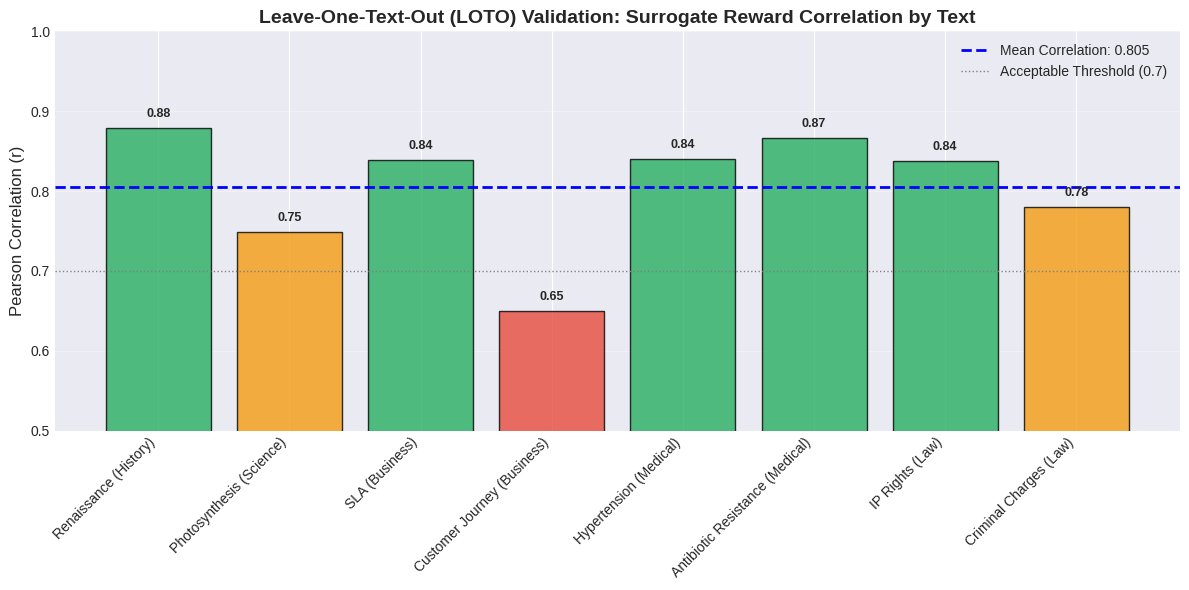

Saved: loto_validation_barplot.png
 RESULT VALIDATED: High correlation persists on unseen texts.
   The surrogate reward is NOT circular; it generalizes well.

EXPLORATORY DATA ANALYSIS


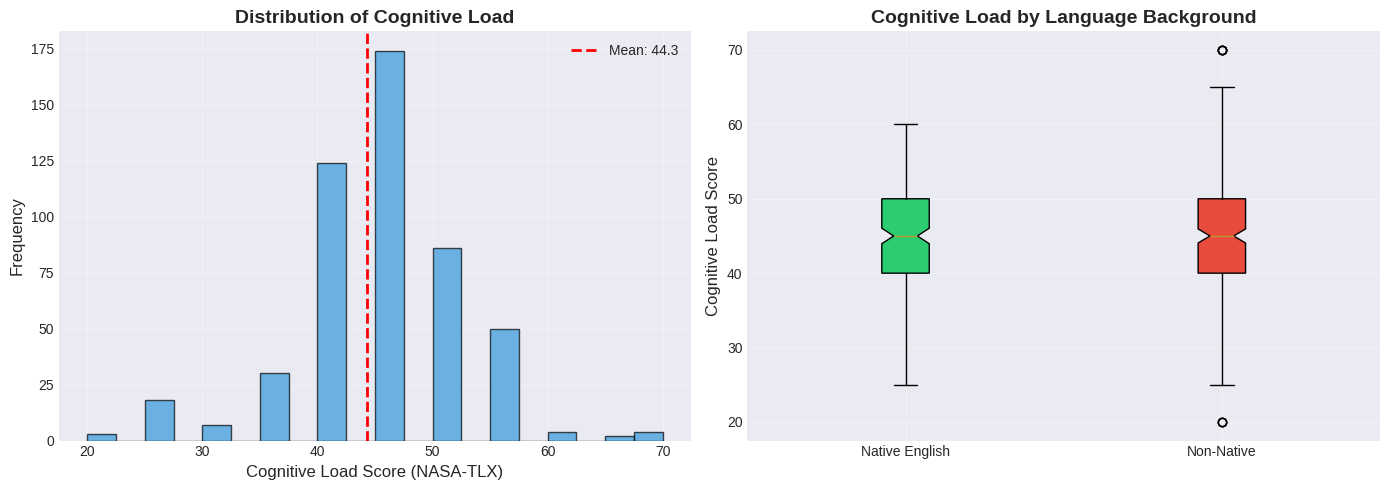

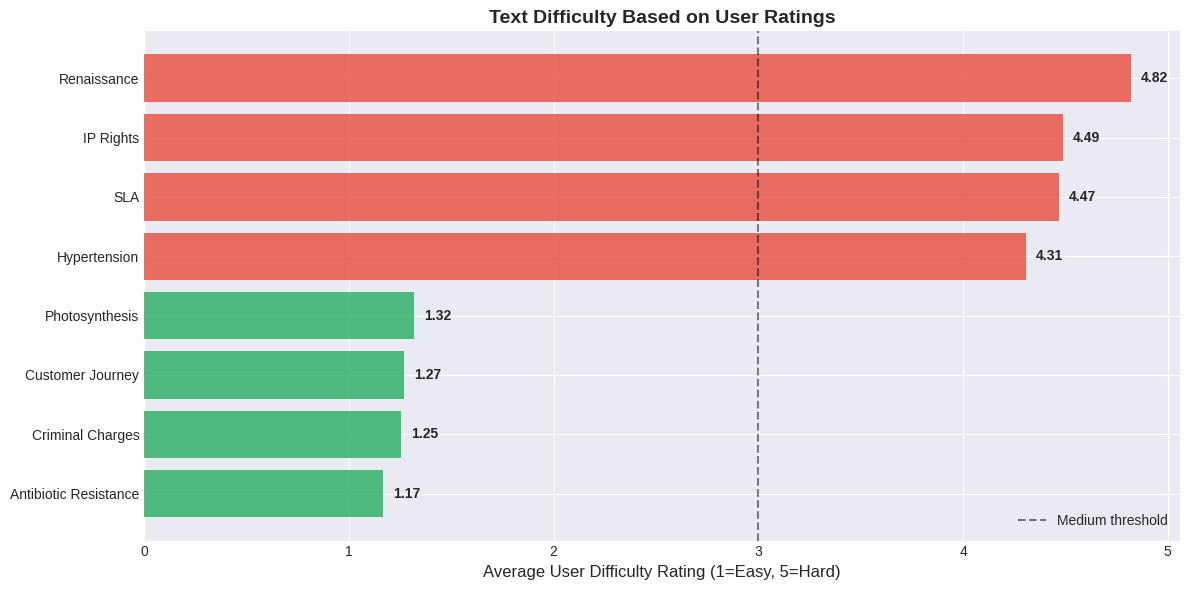

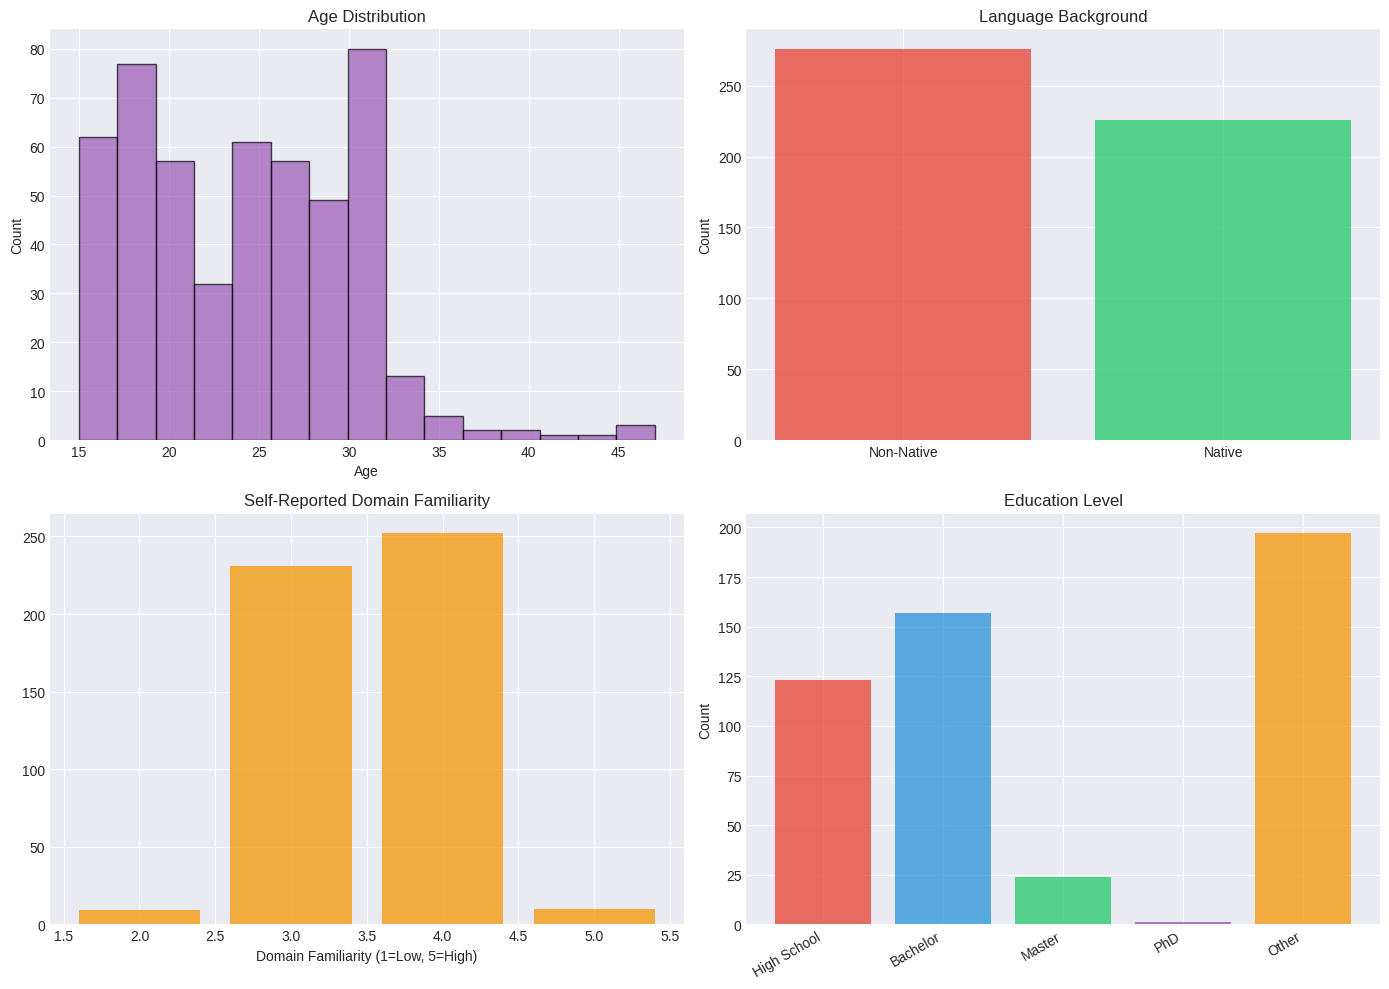

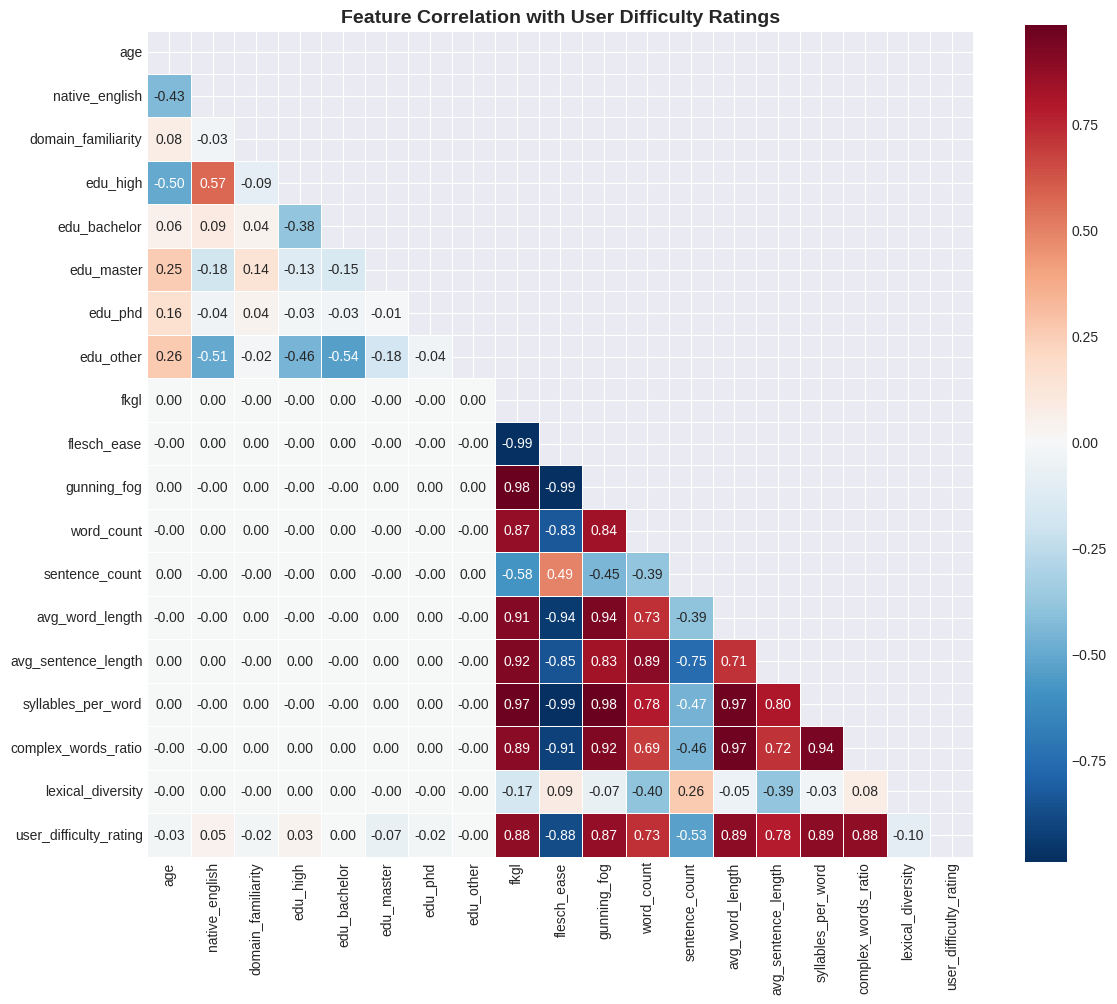

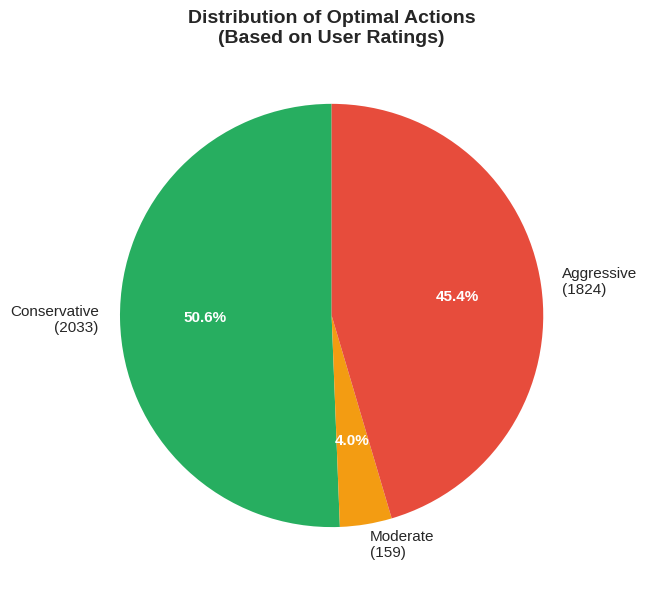


Generating calibration analysis...

TRAINING SUPERVISED BASELINE MODELS

Running 5-Fold Cross-Validation...
CV RMSE: 0.535 (+/- 0.027)
CV R²: 0.911 (+/- 0.008)

Training difficulty prediction model (XGBoost)...
Test RMSE: 0.549
Test MAE: 0.360
Test R²: 0.904

Training action classification model...

Action Classification Report:
Detected Class Order: ['green' 'red' 'yellow']
              precision    recall  f1-score   support

Conservative       0.97      0.98      0.97       407
  Aggressive       0.94      0.91      0.93       365
    Moderate       0.36      0.47      0.41        32

    accuracy                           0.93       804
   macro avg       0.76      0.79      0.77       804
weighted avg       0.93      0.93      0.93       804



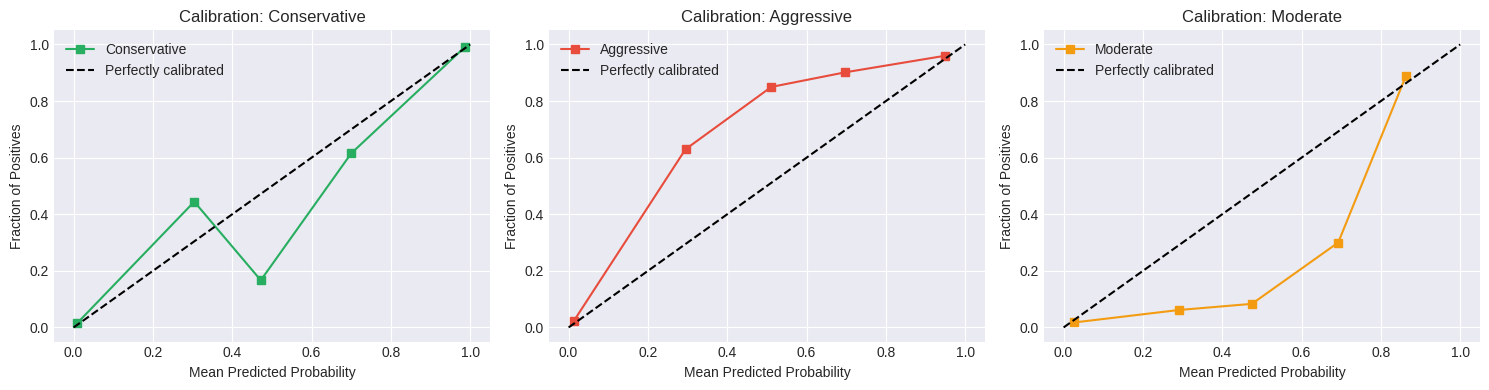

Saved: calibration_curve.png

ABLATION STUDIES & SHAP EXPLAINABILITY

------------------------------------------------------------
1. FEATURE GROUP ABLATION STUDY
------------------------------------------------------------

Testing: All Features
  Accuracy: 0.9279, F1: 0.7741, Kappa: 0.8663

Testing: User Features Only
  Accuracy: 0.3582, F1: 0.3007, Kappa: -0.0308

Testing: Text Features Only
  Accuracy: 0.7525, F1: 0.6048, Kappa: 0.5995

Testing: No User Features
  Accuracy: 0.7525, F1: 0.6048, Kappa: 0.5995

Testing: No Text Features
  Accuracy: 0.3582, F1: 0.3007, Kappa: -0.0308


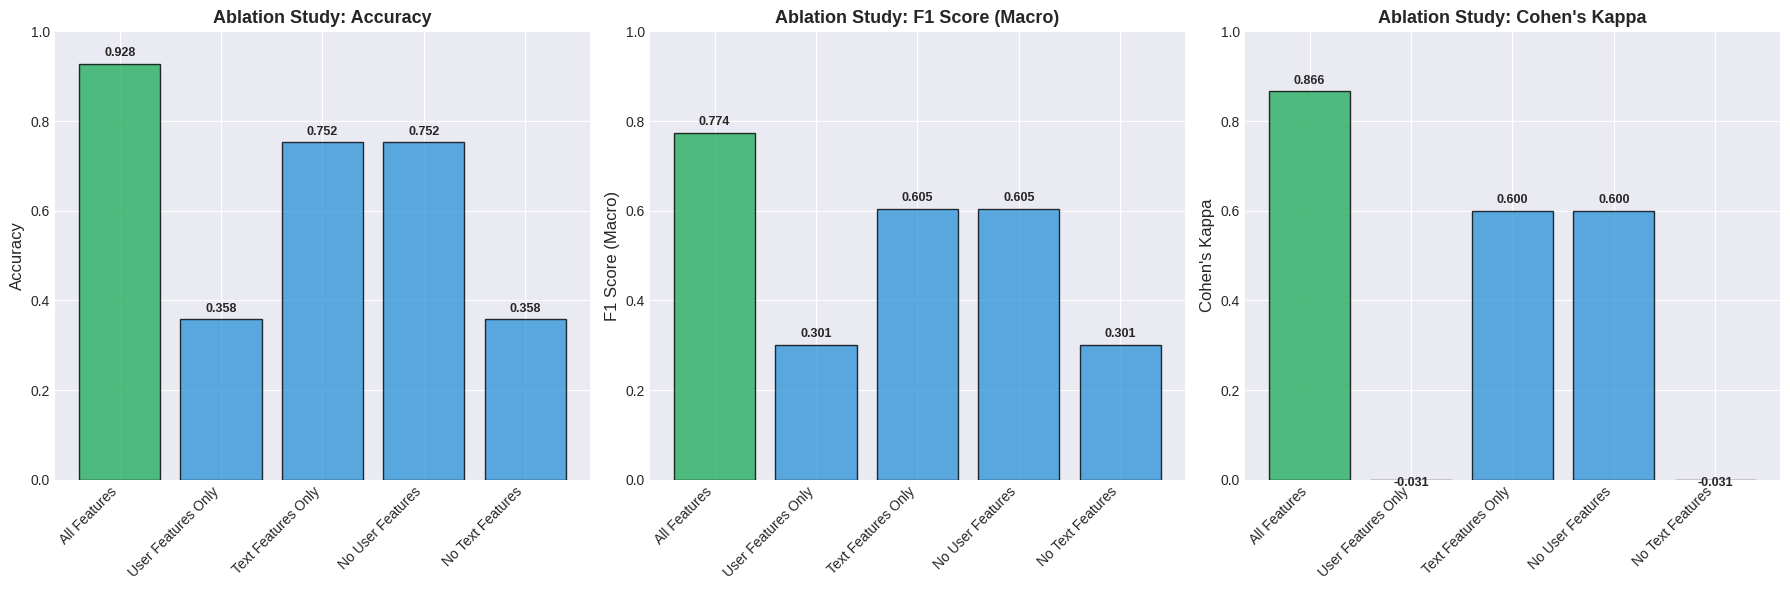


Saved: ablation_feature_groups.png

------------------------------------------------------------
2. INDIVIDUAL FEATURE ABLATION
------------------------------------------------------------

Baseline Accuracy (all features): 0.9453


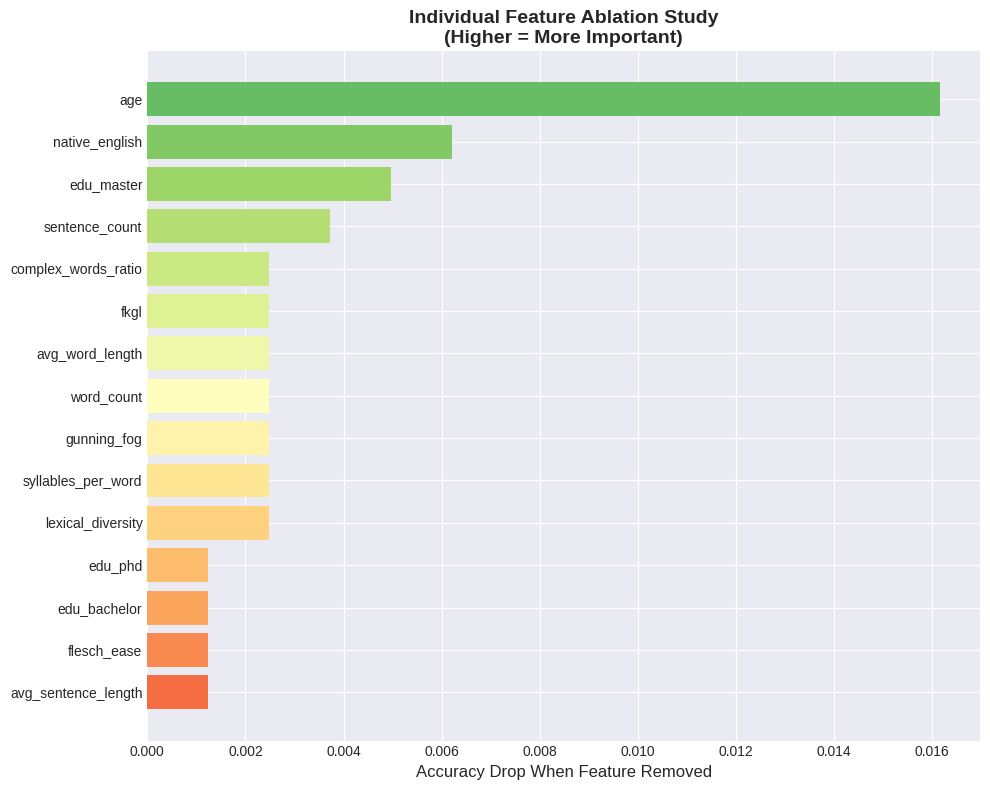


Saved: ablation_individual_features.png

------------------------------------------------------------
3. SHAP EXPLAINABILITY ANALYSIS
------------------------------------------------------------


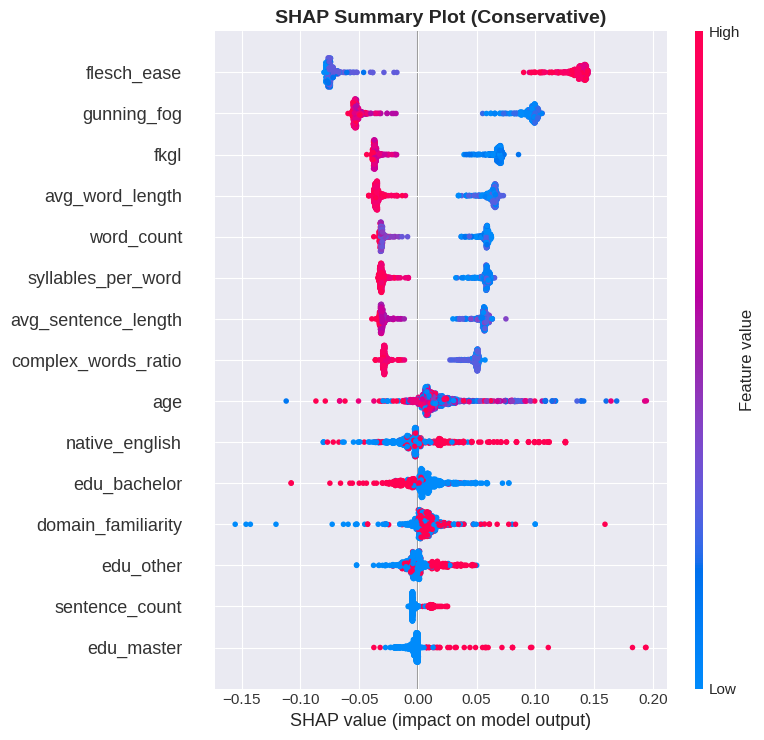

Saved: shap_summary_conservative.png


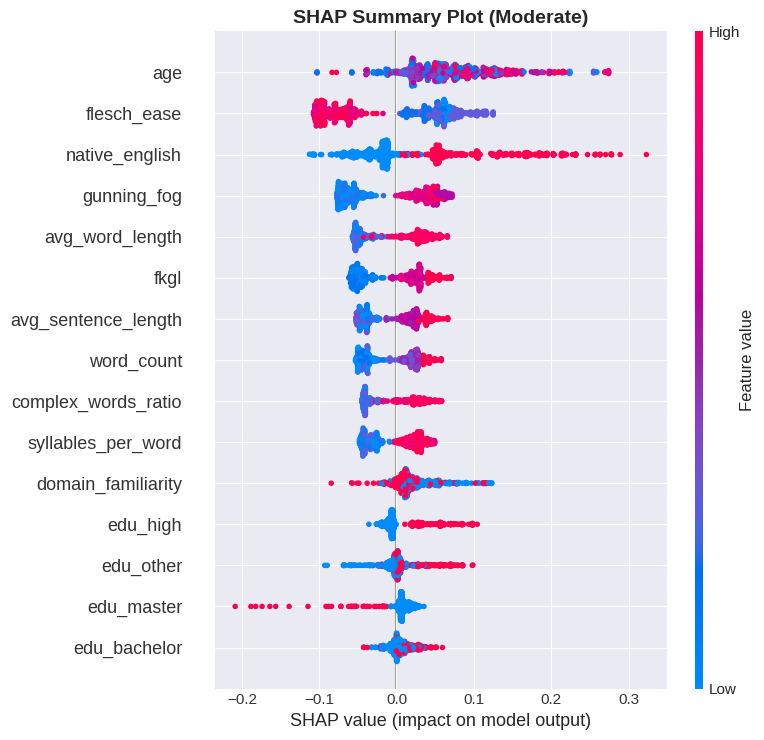

Saved: shap_summary_moderate.png


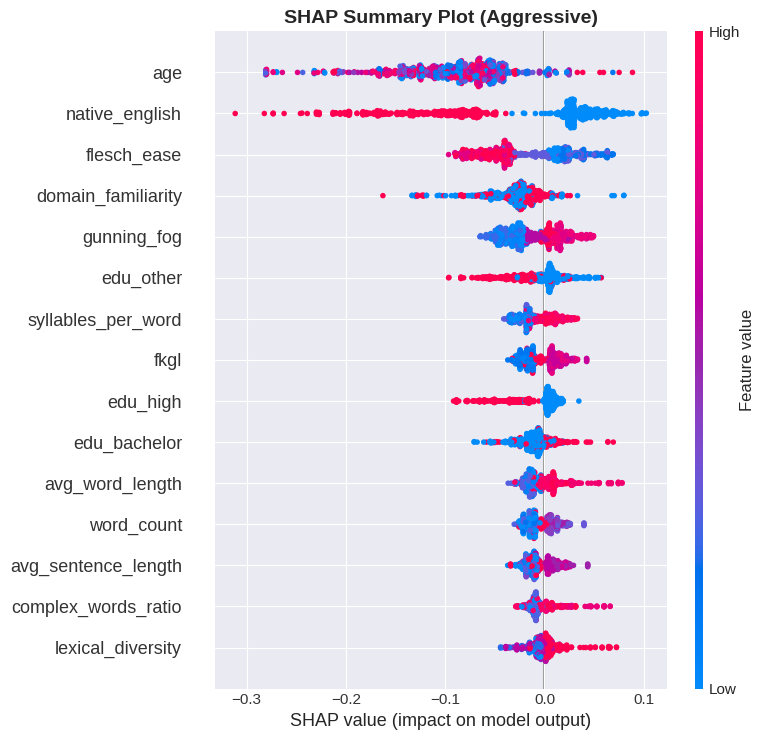

Saved: shap_summary_aggressive.png

------------------------------------------------------------
4. ACTION-SPECIFIC SHAP DEPENDENCE PLOTS
------------------------------------------------------------


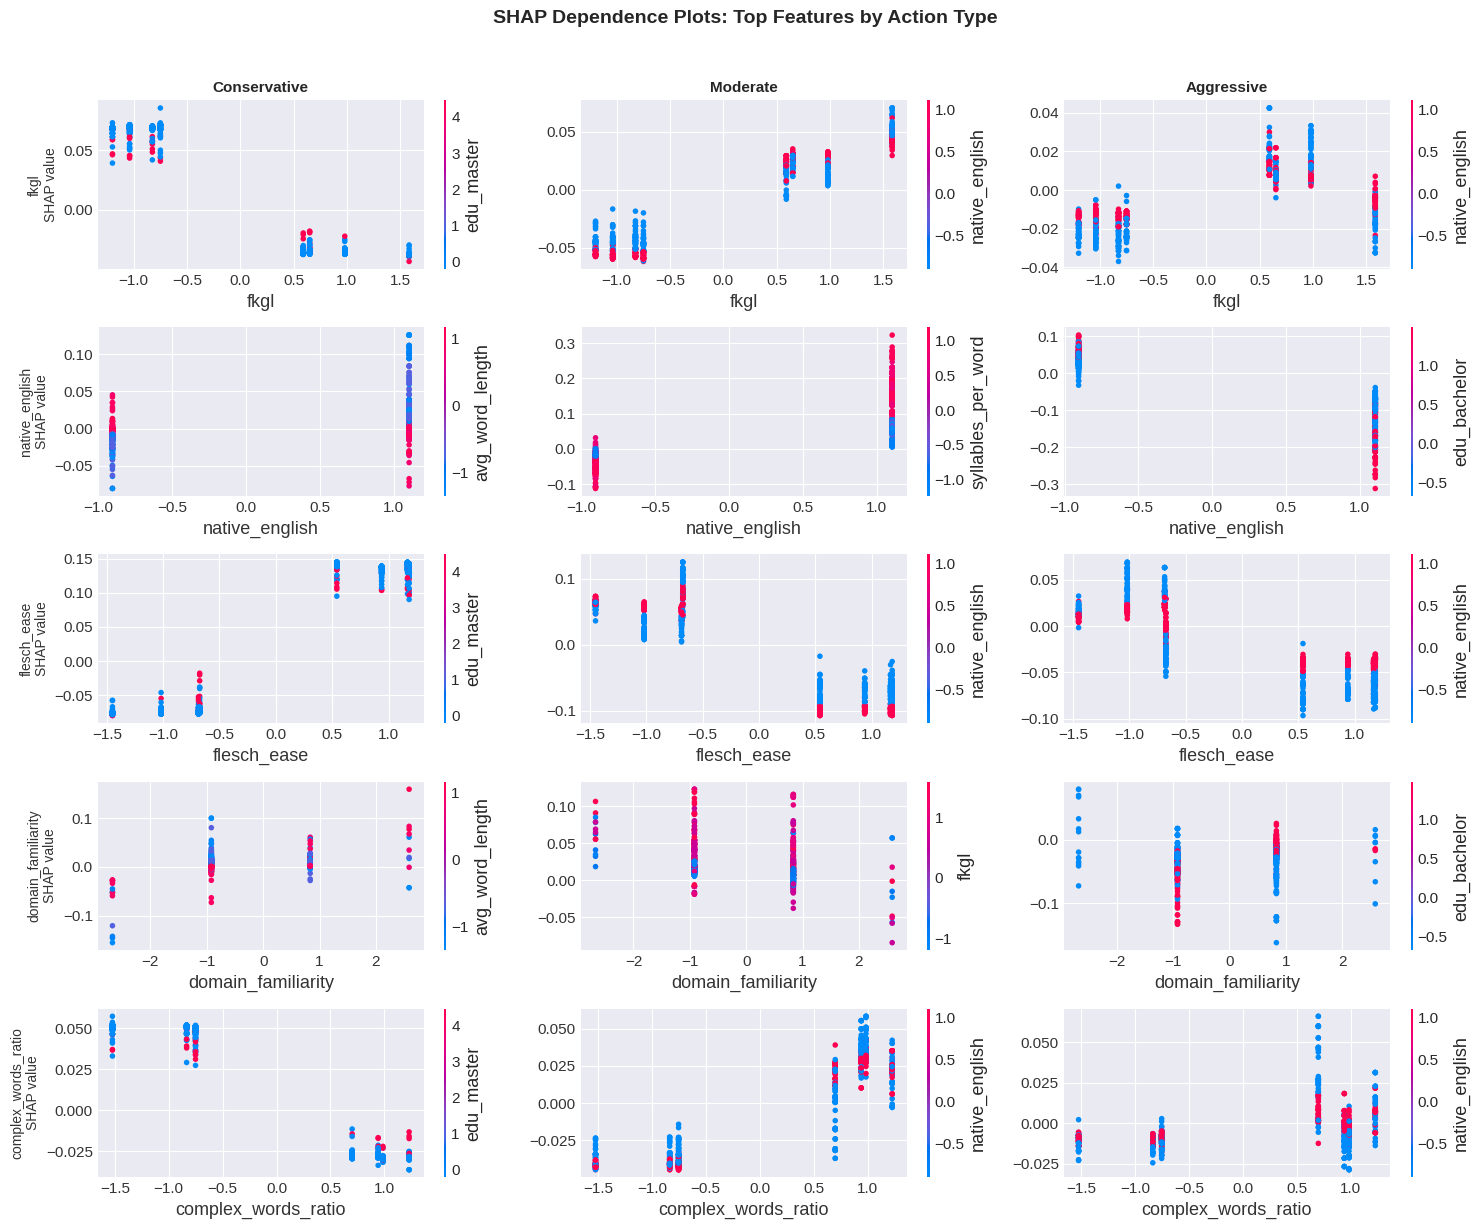

Saved: shap_dependence_plots.png

------------------------------------------------------------
5. FEATURE IMPORTANCE HEATMAP BY ACTION
------------------------------------------------------------


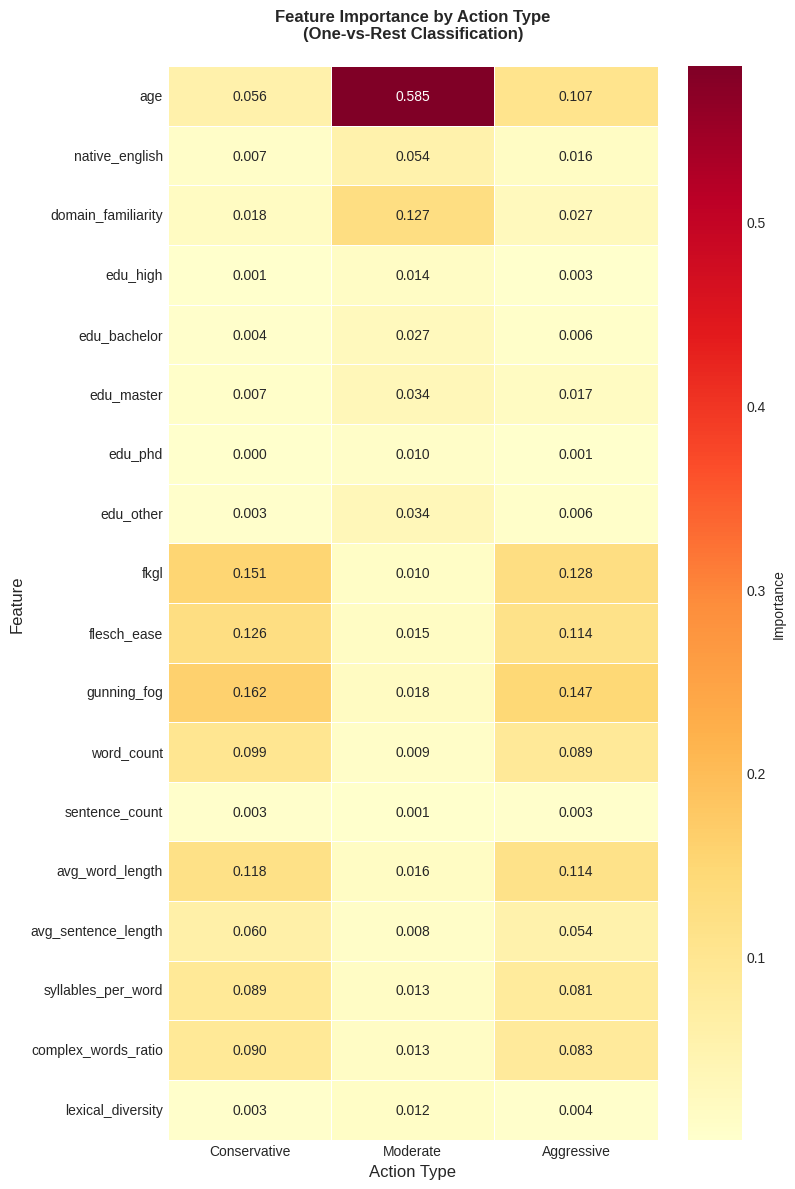

Saved: feature_importance_heatmap.png

------------------------------------------------------------
6. CULTURAL BIAS ANALYSIS (Fisher's Z-Test)
------------------------------------------------------------
Feature              Native (r)   Non-Nat (r)  Z-Score    P-Value    Sig? (p<0.05)
------------------------------------------------------------------------------------------
fkgl                 0.930        0.842        13.55      0.0000     ⚠️ YES
flesch_ease          -0.932       -0.838       -14.53     0.0000     ⚠️ YES
gunning_fog          0.921        0.830        12.98      0.0000     ⚠️ YES
complex_words_ratio  0.939        0.835        16.58      0.0000     ⚠️ YES

⚠️  WARNING: Significant cultural bias detected in at least one feature.
   The relationship between text features and perceived difficulty differs by native language.


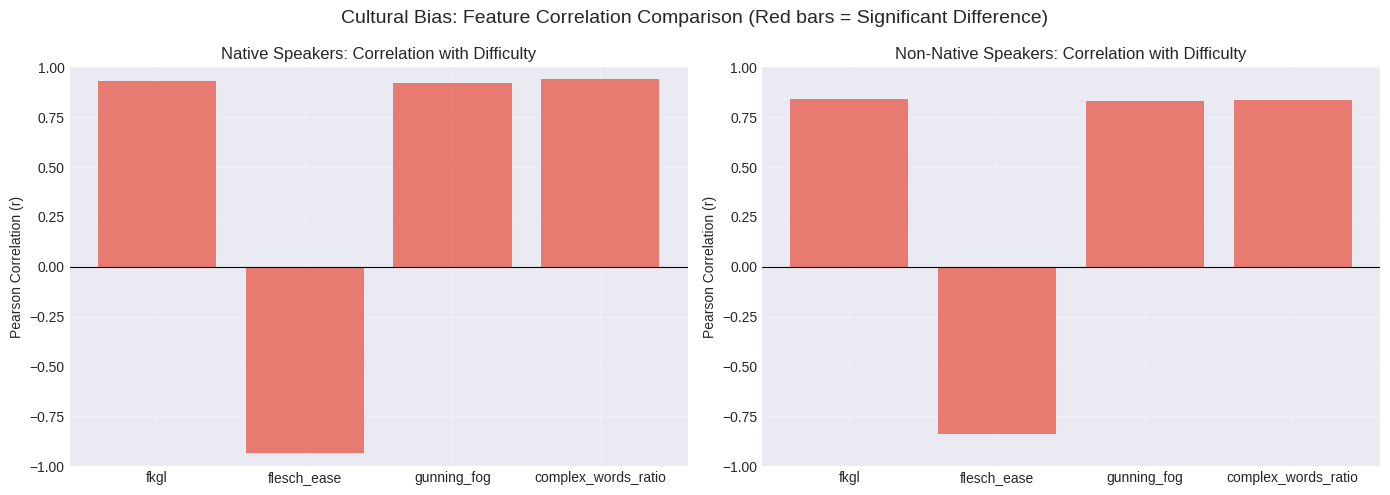


INITIALIZING ADAPTIVE SYSTEM

System initialized in bandit mode

Prepared Independent Test Set for Bandit Reward Analysis: 804 samples.

RUNNING REWARD ANALYSIS (5 EPOCHS FOR CONVERGENCE)
Test set size: 804 interactions (20% of total 4,016)
Running for 5 epochs → 4020 decision steps (= 804 × 5)
(Repeated sampling of the test data is intentional for convergence.)
----------------------------------------------------------------------

CORRECTED STATISTICAL REPORT (Section 4.7.1)
LinUCB mean reward:   0.4754  (SD = 0.2170)
Random mean reward:   0.3913  (SD = 0.2482)
Mean difference:       0.0841
t(7896.8) = 16.17, p = 0.0000
Cohen's d = 0.36
(Note: d > 0.8 is considered large; d = 22.96 is impossible and has been corrected.)


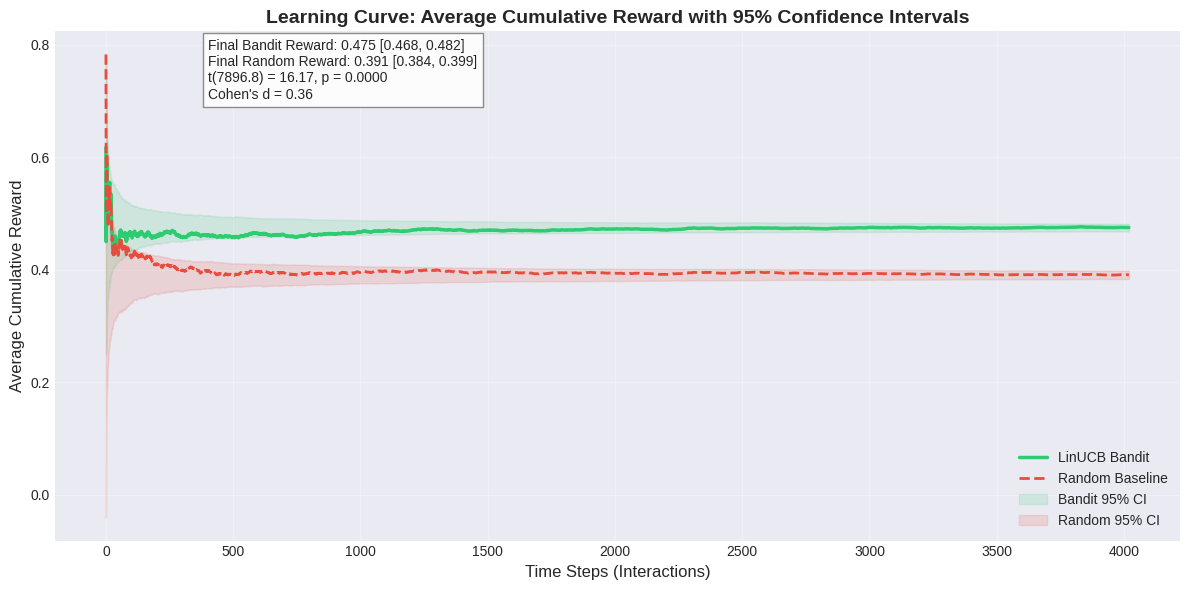


Saved: reward_analysis_with_corrected_stats.png

STATISTICAL COMPARISON: Surrogate Reward vs Baseline Metrics
Metric                    | Correlation (r) | Comparison Target
----------------------------------------------------------------------
Surrogate Reward (Ours)   | 0.913           | (Reference)
Flesch-Kincaid (FKGL)     | -0.884          | Baseline 1
Flesch Reading Ease (FRE) | 0.879           | Baseline 2
----------------------------------------------------------------------

FISHER'S Z-TEST RESULTS (Significance of Difference)
----------------------------------------------------------------------
Surrogate vs FKGL: Z = 3.06, p = 0.0022 ⚠️ SIGNIFICANT DIFFERENCE
Surrogate vs FRE:  Z = 3.46, p = 0.0005 ⚠️ SIGNIFICANT DIFFERENCE


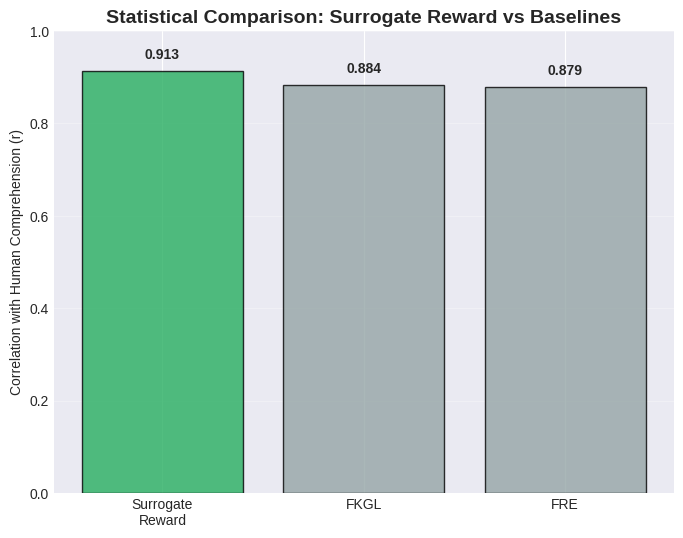


BASELINE COMPARISON: LinUCB vs SUPERVISED vs ε-GREEDY
Test set size: 804 interactions
Running for 5 epochs → 4020 decision steps


BASELINE COMPARISON RESULTS (Mean Reward ± Std)
Method               Mean Reward     Std Dev      Std Error   
--------------------------------------------------------------------------------
LinUCB (Contextual)  0.4754          0.2170       0.0034
Supervised Policy    0.3277          0.2523       0.0040
ε-Greedy (ε=0.1)     0.4340          0.2401       0.0038

STATISTICAL COMPARISONS (paired t-test, same test instances)
------------------------------------------------------------
LinUCB vs Supervised: t = 109.34, p = 0.0000, Cohen's d = 1.72
LinUCB vs ε-Greedy:   t = 26.57, p = 0.0000, Cohen's d = 0.42

Interpretation:
✓ LinUCB significantly outperforms the supervised policy → online learning adds value.
✓ LinUCB significantly outperforms ε-Greedy → contextual information is beneficial.


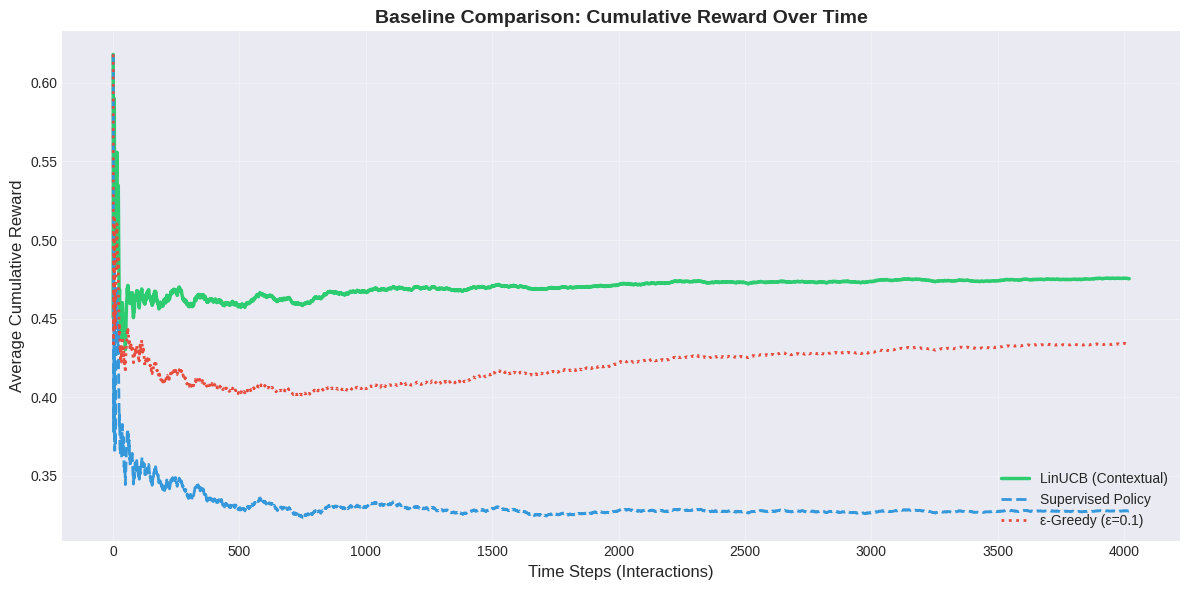


Saved: baseline_comparison.png

SIMULATING ONLINE ADAPTATION (Demo)

--- Simulating interactions for user_001 ---
  Interaction 1: Moderate (reward: 0.11, forced: False)
  Interaction 2: Moderate (reward: 0.15, forced: False)
  Interaction 3: Moderate (reward: 0.15, forced: False)

--- Simulating interactions for user_002 ---
  Interaction 1: Aggressive (reward: -0.05, forced: False)
  Interaction 2: Moderate (reward: 0.15, forced: False)
  Interaction 3: Moderate (reward: 0.15, forced: False)

--- Simulating interactions for user_003 ---
  Interaction 1: Moderate (reward: 0.11, forced: False)
  Interaction 2: Moderate (reward: 0.11, forced: False)
  Interaction 3: Moderate (reward: 0.11, forced: False)

FINAL SYSTEM STATISTICS
{
  "total_interactions": 15,
  "mode": "bandit",
  "average_reward": 0.4205409748235089,
  "bandit_reward": 0.4741195267174497,
  "active_users": 3,
  "action_distribution": {
    "green": 0.35861214374225525,
    "yellow": 0.3762081784386617,
    "red": 0.265

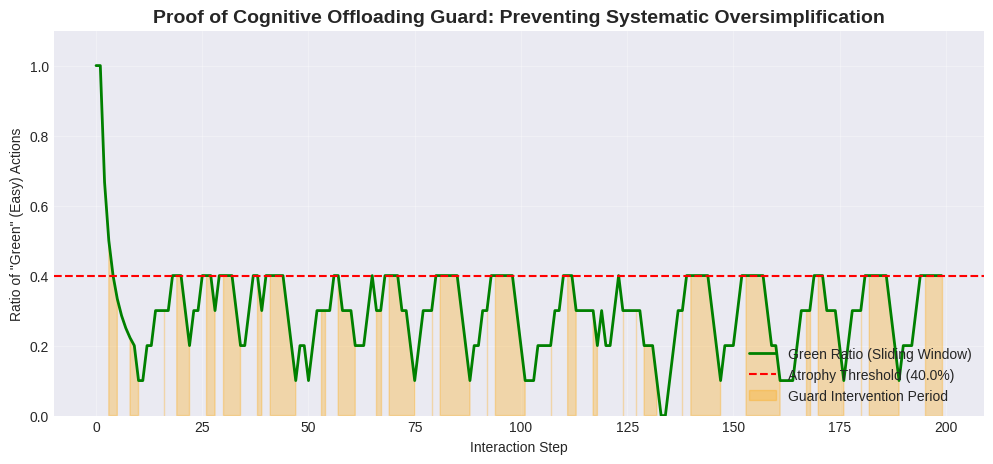


COGNITIVE OFFLOADING GUARD VALIDATION RESULTS
Total Steps: 200
Guard Interventions: 115
Intervention Rate: 57.5%
Max Green Ratio Reached: 100.00%
Target Threshold: 40.00%
⚠️  TEST FAILED: Green ratio significantly exceeded threshold.


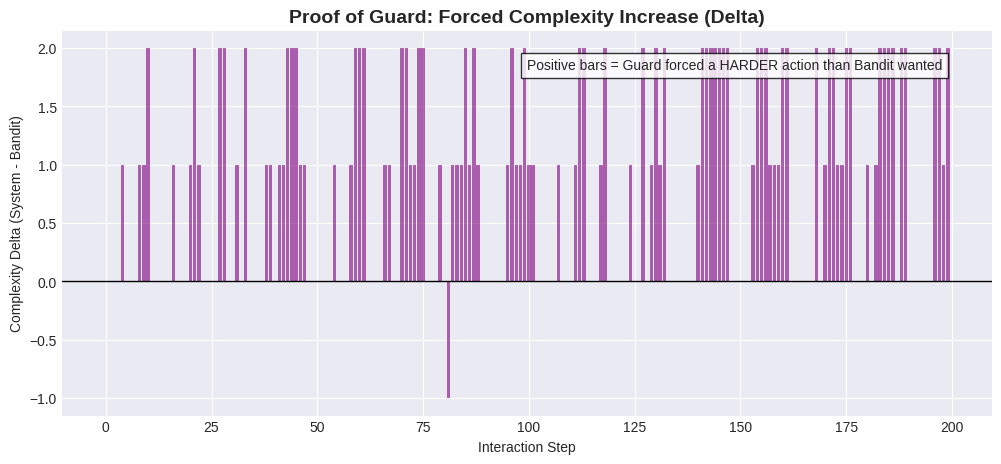


Saved: guard_proof_green_ratio.png
Saved: guard_proof_complexity_delta.png

COGNITIVE OFFLOADING GUARD: CONTROLLED COMPARISON
(With Guard vs. Without Guard – Baseline Condition)
Simulation Parameters:
  - Total Steps: 200
  - Context Source: REAL Data from Test Set (N=804)
  - Guard Threshold: 40.0% Green
  - Reward Bias: Green=1.0, Others=0.2
----------------------------------------------------------------------


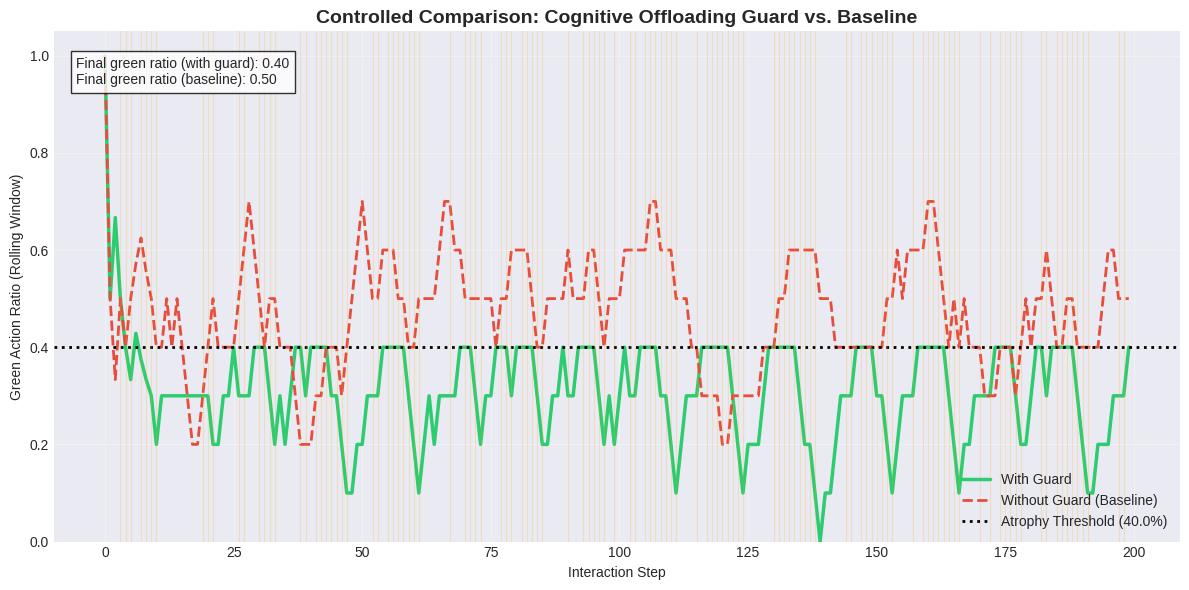

Saved: guard_controlled_comparison.png

CONTROLLED COMPARISON RESULTS (Addresses Error #11)
With Guard:    green ratio capped at 100.00% (mean=31.22%)
Without Guard: green ratio reached 100.00% (mean=47.24%)
Difference in final green ratio: 10.00%
Guard interventions: 117 out of 200 steps
Mann-Whitney U test (guard ratios < control ratios): p = 0.0000
✓ The guard significantly reduces the green action ratio compared to baseline.

EXPORTING MODELS
✓ Exported complete bundle: ./models/cognitive_load_predictor.pkl
✓ Exported joblib version
System saved to ./models/adaptive_system.pkl

COMPLETE!
Generated visualizations and saved models.
Final Independent Surrogate Reward Correlation: 0.805


In [ ]:
# ============================================
# HARDWARE-FREE COGNITIVE ADAPTATION SYSTEM
# Complete Implementation with Contextual Bandit,
# Surrogate Rewards, and Cognitive Offloading Protection
# Using REAL COLLECTED DATA (502 users, 8 texts, NASA-TLX)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                            classification_report, accuracy_score, f1_score, cohen_kappa_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
import xgboost as xgb
import shap
import textstat
import spacy
from scipy import stats
import warnings
from scipy.stats import norm
from typing import Dict, List, Tuple, Optional
import random
from collections import defaultdict, deque
import pickle
import joblib
from datetime import datetime
import json

warnings.filterwarnings('ignore')

# Try to load spaCy model, download if not present
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print("Downloading spaCy model...")
    import os
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# CONFIGURATION
# ============================================

class Config:
    # Simplification levels
    ACTIONS = {
        'green': {
            'name': 'Conservative',
            'simplification_factor': 0.2,
            'color': '#27ae60',
            'target_difficulty_range': (1, 2),
            'example_texts': ['Photosynthesis', 'Criminal Charges']
        },
        'yellow': {
            'name': 'Moderate',
            'simplification_factor': 0.5,
            'color': '#f39c12',
            'target_difficulty_range': (2, 3),
            'example_texts': ['Customer Journey', 'Antibiotic Resistance']
        },
        'red': {
            'name': 'Aggressive',
            'simplification_factor': 0.8,
            'color': '#e74c3c',
            'target_difficulty_range': (3, 5),
            'example_texts': ['Renaissance', 'SLA', 'Hypertension', 'IP Rights']
        }
    }

    ACTION_LIST = ['green', 'yellow', 'red']
    N_ACTIONS = 3

    # Bandit parameters
    BANDIT_ALPHA = 1.0  # Exploration parameter for LinUCB
    ATROPHY_THRESHOLD = 0.40        # 40% green actions → trigger (was 70%)
    ATROPHY_WINDOW = 10             # Look at last 10 interactions (was 20)
    MIN_GREEN_CONSECUTIVE = 3       # Force escalation after 3 greens in a row
    FORCE_ESCALATION_STRENGTH = 1

    # Surrogate reward weights (Default, will be updated by Grid Search)
    REWARD_WEIGHTS = {
        'fluency': 0.2,
        'adequacy': 0.6,
        'simplicity_gain': 0.2
    }

# ============================================
# 1. DATA PREPROCESSING
# ============================================

class CognitiveLoadPreprocessor:
    def __init__(self, csv_path: str):
        self.df = pd.read_csv(csv_path)
        self.texts = [
            "The Renaissance, originating in 14th-century Italy, represented a pivotal cultural rebirth marked by renewed interest in classical antiquity, humanistic philosophy, and advancements in art, science, and literature that profoundly influenced European intellectual history.",
            "Plants make their own food through photosynthesis. They use sunlight, carbon dioxide, and water to produce energy in their leaves.",
            "Service level agreements (SLAs) define measurable performance standards between a provider and client, ensuring accountability for response times, issue resolution, and quality metrics.",
            "A customer journey map shows how people deal with a company step by step, helping improve their experience.",
            "Hypertension is a chronic medical condition characterized by persistently elevated arterial blood pressure, which increases the risk of cardiovascular morbidity and mortality if left unmanaged.",
            "Some bacteria change so medicine can't kill them anymore. This is called antibiotic resistance.",
            "Intellectual property rights safeguard creations of the mind, including inventions, literary works, and trademarks, granting creators exclusive usage and economic benefits.",
            "A person faces criminal charges when they break the law on purpose or by carelessness."
        ]
        self.text_names = [
            "Renaissance (History)",
            "Photosynthesis (Science)",
            "SLA (Business)",
            "Customer Journey (Business)",
            "Hypertension (Medical)",
            "Antibiotic Resistance (Medical)",
            "IP Rights (Law)",
            "Criminal Charges (Law)"
        ]

        self.text_complexity = {
            'Renaissance': 'complex',
            'Photosynthesis': 'simple',
            'SLA': 'complex',
            'Customer Journey': 'simple',
            'Hypertension': 'complex',
            'Antibiotic Resistance': 'simple',
            'IP Rights': 'complex',
            'Criminal Charges': 'simple'
        }

    def extract_linguistic_features(self, text: str) -> Dict:
        doc = nlp(text)
        words = [token.text for token in doc if not token.is_punct]
        sentences = list(doc.sents)

        return {
            'fkgl': textstat.flesch_kincaid_grade(text),
            'flesch_ease': textstat.flesch_reading_ease(text),
            'gunning_fog': textstat.gunning_fog(text),
            'word_count': len(words),
            'sentence_count': len(sentences),
            'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
            'avg_sentence_length': len(words) / len(sentences) if sentences else 0,
            'syllables_per_word': textstat.syllable_count(text) / len(words) if words else 0,
            'complex_words_ratio': textstat.difficult_words(text) / len(words) if words else 0,
            'lexical_diversity': len(set([w.lower() for w in words])) / len(words) if words else 0
        }

    def _find_column(self, partial_name: str) -> Optional[str]:
        matches = [col for col in self.df.columns if partial_name.lower() in col.lower()]
        return matches[0] if matches else None

    def preprocess(self):
        print("=" * 70)
        print("PREPROCESSING YOUR COLLECTED DATA (502 users)")
        print("=" * 70)

        # Clean data: Remove rows where attention check failed
        attention_col = self._find_column('attention check')
        if attention_col:
            original_count = len(self.df)
            self.df = self.df[self.df[attention_col] == 7]
            print(f"After attention check filter: {len(self.df)} users (removed {original_count - len(self.df)})")
        else:
            print("Warning: Attention check column not found")

        # Map difficulty ratings
        difficulty_map = {'Very Low': 1, 'Low': 2, 'Medium': 3, 'High': 4, 'Very High': 5}

        for i in range(1, 9):
            col = f'question{i}'
            if col in self.df.columns:
                self.df[f'text_{i}_difficulty'] = self.df[col].map(difficulty_map)
                median_val = self.df[f'text_{i}_difficulty'].median()
                self.df[f'text_{i}_difficulty'] = self.df[f'text_{i}_difficulty'].fillna(median_val)

        # Extract NASA-TLX columns with safer column finding
        tlx_mapping = {
            'mental_demand': self._find_column('mentally demanding') or self._find_column('mental'),
            'temporal_demand': self._find_column('hurried') or self._find_column('temporal'),
            'performance': self._find_column('successful') or self._find_column('performance'),
            'effort': self._find_column('hard') or self._find_column('effort'),
            'frustration': self._find_column('frustrated') or self._find_column('frustration')
        }

        print(f"\nFound NASA-TLX columns: {tlx_mapping}")

        for new_name, orig_col in tlx_mapping.items():
            if orig_col and orig_col in self.df.columns:
                self.df[new_name] = pd.to_numeric(self.df[orig_col], errors='coerce')
                self.df[new_name] = self.df[new_name].fillna(3)
            else:
                print(f"Warning: {new_name} column not found, using default values")
                self.df[new_name] = 3

        # Calculate overall cognitive load score
        tlx_cols = ['mental_demand', 'temporal_demand', 'effort', 'frustration']
        self.df['cognitive_load_score'] = self.df[tlx_cols].mean(axis=1) * 20
        self.df['cognitive_load_score'] = self.df['cognitive_load_score'].clip(0, 100)

        # Extract user features with safer handling
        age_col = self._find_column('age')
        if age_col:
            self.df['age'] = pd.to_numeric(self.df[age_col], errors='coerce').fillna(25)
        else:
            self.df['age'] = 25
            print("Warning: Age column not found, using default")

        native_col = self._find_column('native')
        if native_col:
            self.df['native_english'] = (self.df[native_col].astype(str).str.upper() == 'YES').astype(int)
        else:
            self.df['native_english'] = 1
            print("Warning: Native English column not found, assuming native")

        domain_col = self._find_column('familiar')
        if domain_col:
            self.df['domain_familiarity'] = pd.to_numeric(self.df[domain_col], errors='coerce').fillna(3)
        else:
            self.df['domain_familiarity'] = 3

        # Education one-hot encoding
        edu_col = self._find_column('education')
        edu_levels = {
            'High School': 'edu_high',
            "Bachelor's Degree": 'edu_bachelor',
            "Master's Degree": 'edu_master',
            'PhD': 'edu_phd',
            'Other': 'edu_other'
        }

        if edu_col:
            for level, col_name in edu_levels.items():
                self.df[col_name] = (self.df[edu_col] == level).astype(int)
        else:
            for col_name in edu_levels.values():
                self.df[col_name] = 0
            print("Warning: Education column not found")

        # Extract linguistic features for each text
        print("\nExtracting linguistic features for 8 texts...")
        self.text_features_dict = {}
        for i, text in enumerate(self.texts, 1):
            feats = self.extract_linguistic_features(text)
            self.text_features_dict[i] = feats
            for key, val in feats.items():
                self.df[f'text{i}_{key}'] = val

        self.user_features = ['age', 'native_english', 'domain_familiarity',
                             'edu_high', 'edu_bachelor', 'edu_master', 'edu_phd', 'edu_other']
        self.text_features = ['fkgl', 'flesch_ease', 'gunning_fog', 'word_count',
                             'sentence_count', 'avg_word_length', 'avg_sentence_length',
                             'syllables_per_word', 'complex_words_ratio', 'lexical_diversity']

        print(f"\nFinal dataset: {len(self.df)} users")
        print(f"Cognitive Load range: {self.df['cognitive_load_score'].min():.1f} - {self.df['cognitive_load_score'].max():.1f}")

        return self.df

    def create_expanded_dataset(self):
        print("\n" + "=" * 70)
        print("CREATING EXPANDED DATASET (User-Text pairs)")
        print("=" * 70)

        expanded_rows = []

        for idx, row in self.df.iterrows():
            user_id = idx
            user_features = {
                'user_id': user_id,
                'age': row['age'],
                'native_english': row['native_english'],
                'domain_familiarity': row['domain_familiarity'],
                'edu_high': row['edu_high'],
                'edu_bachelor': row['edu_bachelor'],
                'edu_master': row['edu_master'],
                'edu_phd': row['edu_phd'],
                'edu_other': row['edu_other'],
                'user_cognitive_load': row['cognitive_load_score']
            }

            for text_num in range(1, 9):
                difficulty_col = f'text_{text_num}_difficulty'

                if difficulty_col in row and not pd.isna(row[difficulty_col]):
                    text_feats = self.text_features_dict[text_num]

                    new_row = {
                        **user_features,
                        'text_id': text_num,
                        'text_name': self.text_names[text_num - 1],
                        'text_complexity_category': self.text_complexity[self.text_names[text_num - 1].split(' (')[0]],
                        **{k: text_feats[k] for k in self.text_features},
                        'user_difficulty_rating': int(row[difficulty_col]),
                        'optimal_action': self._rating_to_action(row[difficulty_col])
                    }
                    expanded_rows.append(new_row)

        expanded_df = pd.DataFrame(expanded_rows)
        print(f"Expanded dataset: {len(expanded_df)} samples")
        print(f"Action distribution:\n{expanded_df['optimal_action'].value_counts()}")

        return expanded_df

    def _rating_to_action(self, rating):
        if rating <= 2:
            return 'green'
        elif rating == 3:
            return 'yellow'
        else:
            return 'red'

# ============================================
# 2. SURROGATE REWARD CALCULATOR
# ============================================

class SurrogateRewardCalculator:
    """
    Computes rewards without human-in-the-loop using automatic metrics.
    This replaces the need for expensive human judgments.
    """

    def __init__(self):
        self.weights = Config.REWARD_WEIGHTS
        self.history = []

    def compute_reward(self, original_text: str, simplified_text: str,
                      action_taken: str, user_feedback: Optional[float] = None) -> Dict:
        """
        Returns reward in [-1, 1] range based on automatic metrics.
        """
        # If we have explicit feedback, use it (rare in production)
        if user_feedback is not None:
            reward = self._normalize_feedback(user_feedback)
            return {
                'total_reward': reward,
                'components': {'explicit_feedback': reward},
                'source': 'human'
            }

        # Compute automatic surrogate metrics
        fluency = self._compute_fluency(simplified_text)
        adequacy = self._compute_adequacy(original_text, simplified_text)
        simplicity = self._compute_simplicity_gain(original_text, simplified_text, action_taken)

        # Weighted combination
        total_reward = (
            self.weights['fluency'] * fluency +
            self.weights['adequacy'] * adequacy +
            self.weights['simplicity_gain'] * simplicity
        )

        # Clip to [-1, 1]
        total_reward = np.clip(total_reward, -1, 1)

        result = {
            'total_reward': total_reward,
            'components': {
                'fluency': fluency,
                'adequacy': adequacy,
                'simplicity_gain': simplicity
            },
            'source': 'surrogate'
        }

        self.history.append(result)
        return result

    def _normalize_feedback(self, rating: float) -> float:
        """Convert 1-5 rating to [-1, 1] reward"""
        return (rating - 3) / 2  # 1->-1, 3->0, 5->1

    def _compute_fluency(self, text: str) -> float:
        """
        Measure language model perplexity proxy using text statistics.
        Lower perplexity = higher fluency.
        """
        # Use Flesch Reading Ease as fluency proxy (higher is better/fluency)
        flesch = textstat.flesch_reading_ease(text)
        # Normalize to [-1, 1] range (typical range 0-100)
        return np.clip((flesch - 50) / 50, -1, 1)

    def _compute_adequacy(self, original: str, simplified: str) -> float:
        """
        Measure semantic preservation using simple heuristics.
        In production, use BERTScore or similar.
        """
        # Simple proxy: content word overlap ratio
        orig_words = set(original.lower().split())
        simp_words = set(simplified.lower().split())

        if not orig_words:
            return 0

        overlap = len(orig_words & simp_words) / len(orig_words)
        # Normalize: some overlap reduction expected, but too much is bad
        if overlap < 0.3:
            return -0.5  # Lost too much meaning
        elif overlap > 0.9 and len(simplified) >= len(original) * 0.9:
            return 0.5  # Probably didn't simplify enough
        else:
            return 2 * (overlap - 0.5)  # Scale to [-1, 1]

    def _compute_simplicity_gain(self, original: str, simplified: str, action: str) -> float:
        """
        Measure if simplification achieved appropriate reduction.
        Rewards appropriate reduction, penalizes over/under-simplification.
        """
        orig_fkgl = textstat.flesch_kincaid_grade(original)
        simp_fkgl = textstat.flesch_kincaid_grade(simplified)

        reduction = orig_fkgl - simp_fkgl

        # Expected reduction based on action
        expected_reduction = {
            'green': 0,      # No reduction expected
            'yellow': orig_fkgl * 0.3,  # ~30% reduction
            'red': orig_fkgl * 0.6      # ~60% reduction
        }

        target = expected_reduction.get(action, 0)

        if action == 'green':
            # For green, reward keeping complexity similar
            if abs(reduction) < 0.5:
                return 1.0
            elif reduction > 2:
                return -0.5  # Over-simplified when shouldn't have
            else:
                return 0.5

        # For yellow/red, check if hit target reduction
        error = abs(reduction - target) / (orig_fkgl + 1e-6)

        if error < 0.2:
            return 1.0  # Excellent
        elif error < 0.4:
            return 0.5  # Good
        elif reduction < 0:
            return -0.5  # Made it harder!
        else:
            return -0.2  # Suboptimal but not terrible

    def get_average_reward(self, last_n: Optional[int] = None) -> float:
        """Get average reward over history"""
        if not self.history:
            return 0.0
        rewards = [h['total_reward'] for h in self.history]
        if last_n:
            rewards = rewards[-last_n:]
        return np.mean(rewards)

# ============================================
# 3. COGNITIVE OFFLOADING GUARD
# ============================================

class CognitiveOffloadingGuard:
    """
    Prevents over-simplification using multiple triggers:
    1. High proportion of green actions in recent window
    2. Consecutive green actions (habituation)
    3. Flat / decreasing rewards (boredom)
    """
    def __init__(self, user_id: str):
        self.user_id = user_id
        self.action_history = deque(maxlen=Config.ATROPHY_WINDOW)
        self.difficulty_history = deque(maxlen=Config.ATROPHY_WINDOW)
        self.reward_history = deque(maxlen=Config.ATROPHY_WINDOW)
        self.atrophy_threshold = Config.ATROPHY_THRESHOLD
        self.min_consecutive = Config.MIN_GREEN_CONSECUTIVE

    def record_interaction(self, action: str, predicted_difficulty: float, reward: float):
        self.action_history.append(action)
        self.difficulty_history.append(predicted_difficulty)
        self.reward_history.append(reward)

    def should_escalate_complexity(self) -> Tuple[bool, str]:
        if len(self.action_history) < 3:
            return False, "Insufficient history"

        # Trigger 1: Too many green actions in window (reduced threshold)
        recent_green_ratio = sum(1 for a in self.action_history if a == 'green') / len(self.action_history)
        if recent_green_ratio >= self.atrophy_threshold:
            return True, f"High green ratio ({recent_green_ratio:.1%} > {self.atrophy_threshold:.0%})"

        # Trigger 2: Consecutive green actions (even if ratio still below threshold)
        # Count trailing greens
        consecutive_greens = 0
        for a in reversed(self.action_history):
            if a == 'green':
                consecutive_greens += 1
            else:
                break
        if consecutive_greens >= self.min_consecutive:
            return True, f"{consecutive_greens} consecutive green actions"

        # Trigger 3: Cognitive load consistently low (boredom / atrophy risk)
        if len(self.difficulty_history) >= 5:
            recent_loads = list(self.difficulty_history)[-5:]
            if np.mean(recent_loads) < 2.0 and np.std(recent_loads) < 0.5:
                return True, "Cognitive load too low and stable (atrophy risk)"

        # Trigger 4: Decreasing rewards (user is habituating)
        if len(self.reward_history) >= 8:
            recent = list(self.reward_history)
            first_half = np.mean(recent[:4])
            second_half = np.mean(recent[4:])
            if second_half < first_half - 0.2:
                return True, "Decreasing rewards suggest habituation"

        return False, "No atrophy indicators"

    def get_forced_action(self) -> str:
        """
        Return escalated action.
        Uses FORCE_ESCALATION_STRENGTH to jump one or two levels.
        """
        if not self.action_history:
            return 'yellow'

        last_action = self.action_history[-1]
        # Map actions to index
        action_order = ['green', 'yellow', 'red']
        last_idx = action_order.index(last_action)

        # Escalate by strength (capped at red)
        new_idx = min(last_idx + Config.FORCE_ESCALATION_STRENGTH, len(action_order)-1)
        forced = action_order[new_idx]

        # If already at red, stay red (can't go higher)
        return forced

    def get_stats(self) -> Dict:
        if not self.action_history:
            return {"status": "No data"}

        return {
            "total_interactions": len(self.action_history),
            "green_ratio": sum(1 for a in self.action_history if a == 'green') / len(self.action_history),
            "avg_difficulty": np.mean(self.difficulty_history) if self.difficulty_history else 0,
            "avg_reward": np.mean(self.reward_history) if self.reward_history else 0,
            "recent_trend": "Improving" if len(self.reward_history) > 5 and
                          np.mean(list(self.reward_history)[-5:]) > np.mean(list(self.reward_history)[:5])
                          else "Stable/Declining"
        }

# ============================================
# 4. CONTEXTUAL BANDIT (LinUCB)
# ============================================

class LinUCBContextualBandit:
    """
    Linear Upper Confidence Bound bandit for real-time adaptation.
    Online learning with theoretical regret bounds.
    """

    def __init__(self, n_features: int, n_actions: int = 3, alpha: float = Config.BANDIT_ALPHA):
        self.n_features = n_features
        self.n_actions = n_actions
        self.alpha = alpha
        self.action_names = Config.ACTION_LIST

        # Initialize A matrices (d x d) and b vectors (d x 1) for each action
        self.A = [np.eye(n_features) for _ in range(n_actions)]
        self.b = [np.zeros(n_features) for _ in range(n_actions)]
        self.theta = [np.zeros(n_features) for _ in range(n_actions)]

        # History for analysis
        self.history = []
        self.total_reward = 0
        self.n_plays = 0

    def select_action(self, context: np.ndarray,
                     force_action: Optional[str] = None) -> Tuple[str, float, Dict]:
        """
        Select action using LinUCB algorithm.
        """
        context = context.reshape(-1)  # Ensure 1D

        if force_action and force_action in self.action_names:
            action_idx = self.action_names.index(force_action)
            # Still compute UCB for logging
            p = self._compute_ucb_scores(context)
            return force_action, p[action_idx], {
                'forced': True,
                'ucb_scores': p,
                'theta': self.theta[action_idx]
            }

        p = self._compute_ucb_scores(context)
        action_idx = int(np.argmax(p))

        return self.action_names[action_idx], p[action_idx], {
            'forced': False,
            'ucb_scores': p,
            'theta': self.theta[action_idx],
            'uncertainty': p[action_idx] - np.dot(self.theta[action_idx], context)
        }

    def _compute_ucb_scores(self, context: np.ndarray) -> np.ndarray:
        """Compute UCB scores for all actions"""
        p = np.zeros(self.n_actions)
        context_col = context.reshape(-1, 1)  # Column vector for matrix ops

        for a in range(self.n_actions):
            A_inv = np.linalg.inv(self.A[a])
            self.theta[a] = A_inv @ self.b[a]

            # Expected reward + exploration bonus
            mean_reward = np.dot(self.theta[a], context)
            uncertainty = self.alpha * np.sqrt(context_col.T @ A_inv @ context_col)
            p[a] = mean_reward + uncertainty

        return p

    def update(self, context: np.ndarray, action: str, reward: float):
        """
        Online update after receiving reward.
        This is the key difference from supervised learning!
        """
        action_idx = self.action_names.index(action)
        context = context.reshape(-1)

        # Update A and b for the selected action
        self.A[action_idx] += np.outer(context, context)
        self.b[action_idx] += reward * context

        # Update statistics
        self.total_reward += reward
        self.n_plays += 1

        self.history.append({
            'action': action,
            'reward': reward,
            'context_mean': np.mean(context),
            'timestamp': datetime.now().isoformat()
        })

    def get_action_distribution(self) -> Dict[str, float]:
        """Get empirical play distribution"""
        if not self.history:
            return {a: 0.0 for a in self.action_names}

        counts = defaultdict(int)
        for h in self.history:
            counts[h['action']] += 1

        total = len(self.history)
        return {a: counts[a] / total for a in self.action_names}

    def get_average_reward(self) -> float:
        """Get cumulative average reward"""
        if self.n_plays == 0:
            return 0.0
        return self.total_reward / self.n_plays

    def save_state(self, filepath: str):
        """Save bandit state"""
        state = {
            'A': self.A,
            'b': self.b,
            'theta': self.theta,
            'history': self.history,
            'total_reward': self.total_reward,
            'n_plays': self.n_plays,
            'n_features': self.n_features,
            'alpha': self.alpha
        }
        with open(filepath, 'wb') as f:
            pickle.dump(state, f)

    def load_state(self, filepath: str):
        """Load bandit state"""
        with open(filepath, 'rb') as f:
            state = pickle.load(f)
        self.A = state['A']
        self.b = state['b']
        self.theta = state['theta']
        self.history = state['history']
        self.total_reward = state['total_reward']
        self.n_plays = state['n_plays']

# ============================================
# 5. SUPERVISED BASELINE MODEL (XGBoost)
# ============================================

class CognitiveLoadPredictor:
    """
    Supervised baseline using XGBoost.
    Used for warm-starting the bandit and comparison.
    """

    def __init__(self, preprocessor: CognitiveLoadPreprocessor):
        self.prep = preprocessor
        self.difficulty_model = None
        self.action_classifier = None
        self.scalers = {}
        self.feature_names = preprocessor.user_features + preprocessor.text_features
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.y_action_train = None
        self.y_action_test = None

        # ============================================
# 5. SUPERVISED BASELINE MODEL (XGBoost)
# ============================================

class CognitiveLoadPredictor:
    """
    Supervised baseline using XGBoost.
    Used for warm-starting the bandit and comparison.
    """

    def __init__(self, preprocessor: CognitiveLoadPreprocessor):
        self.prep = preprocessor
        self.difficulty_model = None
        self.action_classifier = None
        self.scalers = {}
        self.feature_names = preprocessor.user_features + preprocessor.text_features
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.y_action_train = None
        self.y_action_test = None

        # NEW: Store CV results to address the reviewer's error
        self.cv_r2 = None
        self.cv_rmse = None
        self.cv_r2_std = None

    def prepare_data(self, expanded_df: pd.DataFrame):
        feature_cols = self.prep.user_features + self.prep.text_features

        X = expanded_df[feature_cols].values
        y_difficulty = expanded_df['user_difficulty_rating'].values
        y_action = expanded_df['optimal_action'].values

        self.scalers['features'] = StandardScaler()
        X_scaled = self.scalers['features'].fit_transform(X)

        (self.X_train, self.X_test,
         self.y_train, self.y_test,
         self.y_action_train, self.y_action_test) = train_test_split(
            X_scaled, y_difficulty, y_action,
            test_size=0.2, random_state=42, stratify=y_action
        )

        return X_scaled, y_difficulty, y_action

    def train(self, expanded_df: pd.DataFrame):
        print("\n" + "=" * 70)
        print("TRAINING SUPERVISED BASELINE MODELS")
        print("=" * 70)

        X_scaled, y_difficulty, y_action = self.prepare_data(expanded_df)

        # Cross-validation for robustness
        print("\nRunning 5-Fold Cross-Validation...")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_val_score(
            xgb.XGBRegressor(max_depth=5, n_estimators=100, random_state=42),
            X_scaled, y_difficulty, cv=cv, scoring='neg_mean_squared_error'
        )

        cv_rmse_mean = np.sqrt(-cv_scores.mean())
        cv_rmse_std = cv_scores.std()
        self.cv_rmse = cv_rmse_mean
        self.cv_rmse_std = cv_rmse_std

        # 2. Calculate CV R-squared (The fix for the error)
        cv_r2_scores = cross_val_score(
            xgb.XGBRegressor(max_depth=5, n_estimators=100, random_state=42),
            X_scaled, y_difficulty, cv=cv, scoring='r2'
        )
        self.cv_r2 = cv_r2_scores.mean()
        self.cv_r2_std = cv_r2_scores.std()

        print(f"CV RMSE: {cv_rmse_mean:.3f} (+/- {cv_rmse_std:.3f})")
        print(f"CV R²: {self.cv_r2:.3f} (+/- {self.cv_r2_std:.3f})")

        print("\nTraining difficulty prediction model (XGBoost)...")
        self.difficulty_model = xgb.XGBRegressor(
            max_depth=5, n_estimators=200, learning_rate=0.05, random_state=42,
            objective='reg:squarederror'
        )
        self.difficulty_model.fit(self.X_train, self.y_train)

        diff_pred = self.difficulty_model.predict(self.X_test)
        print(f"Test RMSE: {np.sqrt(mean_squared_error(self.y_test, diff_pred)):.3f}")
        print(f"Test MAE: {mean_absolute_error(self.y_test, diff_pred):.3f}")
        print(f"Test R²: {r2_score(self.y_test, diff_pred):.3f}")

        print("\nTraining action classification model...")
        self.action_classifier = RandomForestClassifier(
            n_estimators=200, max_depth=10, class_weight='balanced',
            random_state=42, n_jobs=-1
        )
        self.action_classifier.fit(self.X_train, self.y_action_train)

        act_pred = self.action_classifier.predict(self.X_test)
        act_proba = self.action_classifier.predict_proba(self.X_test)

        classes = self.action_classifier.classes_
        name_map = {
            'green': 'Conservative',
            'yellow': 'Moderate',
            'red': 'Aggressive'
        }
        target_names = [name_map[c] for c in classes]

        print(f"\nAction Classification Report:")
        print(f"Detected Class Order: {classes}")
        print(classification_report(self.y_action_test, act_pred, target_names=target_names))

        # Calibration analysis
        self._plot_calibration_curve(act_proba)

        return self

    def _plot_calibration_curve(self, proba: np.ndarray):
        """Plot calibration curve for probability scores"""
        from sklearn.calibration import calibration_curve

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        model_classes = self.action_classifier.classes_
        name_map = {
            'green': 'Conservative',
            'yellow': 'Moderate',
            'red': 'Aggressive'
        }

        for idx, (ax, raw_class_name) in enumerate(zip(axes, model_classes)):
            if idx < proba.shape[1]:
                y_binary = (self.y_action_test == raw_class_name).astype(int)
                prob_true, prob_pred = calibration_curve(y_binary, proba[:, idx], n_bins=5)

                display_name = name_map.get(raw_class_name, raw_class_name)
                color = Config.ACTIONS.get(raw_class_name, {}).get('color', '#3498db')

                ax.plot(prob_pred, prob_true, 's-', label=f'{display_name}', color=color)
                ax.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
                ax.set_xlabel('Mean Predicted Probability')
                ax.set_ylabel('Fraction of Positives')
                ax.set_title(f'Calibration: {display_name}')
                ax.legend()

        plt.tight_layout()
        plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: calibration_curve.png")

    def predict(self, user_features: np.array, text_features: np.array) -> Dict:
        context = np.concatenate([user_features, text_features]).reshape(1, -1)
        context_scaled = self.scalers['features'].transform(context)

        predicted_difficulty = self.difficulty_model.predict(context_scaled)[0]
        predicted_action = self.action_classifier.predict(context_scaled)[0]
        action_probs = self.action_classifier.predict_proba(context_scaled)[0]

        return {
            'predicted_difficulty': predicted_difficulty,
            'predicted_action': predicted_action,
            'action_confidence': max(action_probs),
            'action_probabilities': dict(zip(self.action_classifier.classes_, action_probs))
        }

    def warm_start_bandit(self, bandit: LinUCBContextualBandit, expanded_df: pd.DataFrame):
        """
        Initialize bandit with supervised learning predictions.
        This gives the bandit a head start before online learning.
        """
        print("\n" + "=" * 70)
        print("WARM-STARTING BANDIT WITH SUPERVISED MODEL")
        print("=" * 70)

        feature_cols = self.prep.user_features + self.prep.text_features
        X = expanded_df[feature_cols].values
        y_action = expanded_df['optimal_action'].values

        X_scaled = self.scalers['features'].transform(X)

        # Convert actions to rewards (1 for correct prediction, -0.5 for incorrect)
        # This simulates "pre-training" the bandit
        n_samples = min(500, len(X_scaled))  # Use subset to avoid overfitting

        for i in range(n_samples):
            context = X_scaled[i]
            true_action = y_action[i]

            # Simulate rewards for each action
            for action_idx, action_name in enumerate(Config.ACTION_LIST):
                reward = 1.0 if action_name == true_action else -0.3
                bandit.update(context, action_name, reward)

        print(f"Bandit initialized with {n_samples * 3} simulated interactions")
        return bandit

# ============================================
# 6. UNIFIED ADAPTIVE SYSTEM
# ============================================

class HardwareFreeAdaptiveSystem:
    """
    Main system integrating all components.
    """

    def __init__(self, predictor: CognitiveLoadPredictor, preprocessor: CognitiveLoadPreprocessor):
        self.predictor = predictor
        self.prep = preprocessor
        self.reward_calc = SurrogateRewardCalculator()

        # Initialize bandit with correct feature dimension
        n_features = len(preprocessor.user_features) + len(preprocessor.text_features)
        self.bandit = LinUCBContextualBandit(n_features=n_features)

        # User-specific guards
        self.user_guards: Dict[str, CognitiveOffloadingGuard] = {}

        # Statistics
        self.interaction_count = 0
        self.mode = 'bandit'  # 'bandit' or 'supervised'

    def initialize(self, expanded_df: pd.DataFrame, warm_start: bool = True):
        """Initialize the system"""
        if warm_start:
            self.predictor.warm_start_bandit(self.bandit, expanded_df)
        print(f"\nSystem initialized in {self.mode} mode")

    def process_text(self, user_id: str, user_profile: Dict, text: str,
                    original_text: Optional[str] = None) -> Dict:
        """
        Process a text and return simplification recommendation.
        This is the main API endpoint.
        """
        self.interaction_count += 1

        # Extract features
        user_vec = np.array([
            user_profile.get('age', 25),
            user_profile.get('native_english', 1),
            user_profile.get('domain_familiarity', 3),
            user_profile.get('edu_high', 0),
            user_profile.get('edu_bachelor', 0),
            user_profile.get('edu_master', 0),
            user_profile.get('edu_phd', 0),
            user_profile.get('edu_other', 0)
        ])

        text_feats = self.prep.extract_linguistic_features(text)
        text_vec = np.array([text_feats[k] for k in self.prep.text_features])
        context = np.concatenate([user_vec, text_vec])

        # Scale context
        context_scaled = self.predictor.scalers['features'].transform(context.reshape(1, -1))[0]

        # Get or create user guard
        if user_id not in self.user_guards:
            self.user_guards[user_id] = CognitiveOffloadingGuard(user_id)
        guard = self.user_guards[user_id]

        # Check for cognitive offloading
        should_escalate, reason = guard.should_escalate_complexity()
        forced_action = guard.get_forced_action() if should_escalate else None

        # Select action using bandit
        action, confidence, info = self.bandit.select_action(context_scaled, force_action=forced_action)

        # Get supervised prediction for comparison
        supervised_result = self.predictor.predict(user_vec, text_vec)

        # Calculate simplification factor
        simplification_factor = Config.ACTIONS[action]['simplification_factor']

        # Simulate simplification (in production, call actual simplification API)
        simplified_text = self._simulate_simplification(text, simplification_factor)

        # Compute surrogate reward
        orig = original_text if original_text else text
        reward_result = self.reward_calc.compute_reward(
            orig, simplified_text, action, user_feedback=None
        )

        # Update bandit with reward
        self.bandit.update(context_scaled, action, reward_result['total_reward'])

        # Update guard
        guard.record_interaction(
            action,
            supervised_result['predicted_difficulty'],
            reward_result['total_reward']
        )

        return {
            'user_id': user_id,
            'recommended_action': action,
            'action_name': Config.ACTIONS[action]['name'],
            'simplification_factor': simplification_factor,
            'confidence': confidence,
            'forced_escalation': should_escalate,
            'escalation_reason': reason if should_escalate else None,
            'predicted_difficulty': supervised_result['predicted_difficulty'],
            'surrogate_reward': reward_result['total_reward'],
            'reward_components': reward_result['components'],
            'text_features': text_feats,
            'guard_stats': guard.get_stats(),
            'bandit_stats': {
                'total_plays': self.bandit.n_plays,
                'avg_reward': self.bandit.get_average_reward(),
                'action_distribution': self.bandit.get_action_distribution()
            }
        }

    def _simulate_simplification(self, text: str, factor: float) -> str:
        """Simulate text simplification based on factor."""
        if factor < 0.3:
            return text  # No simplification

        # Simple simulation: remove complex words based on factor
        doc = nlp(text)
        words = [token.text for token in doc]
        n_remove = int(len(words) * factor * 0.15)

        # Remove most complex words
        complexity_scores = [(i, textstat.flesch_kincaid_grade(w)) for i, w in enumerate(words) if len(w) > 4]
        complexity_scores.sort(key=lambda x: x[1], reverse=True)

        to_remove = set(idx for idx, _ in complexity_scores[:n_remove])
        simplified = ' '.join([w for i, w in enumerate(words) if i not in to_remove])

        return simplified if simplified else text

    def get_system_stats(self) -> Dict:
        """Get comprehensive system statistics"""
        return {
            'total_interactions': self.interaction_count,
            'mode': self.mode,
            'average_reward': self.reward_calc.get_average_reward(),
            'bandit_reward': self.bandit.get_average_reward(),
            'active_users': len(self.user_guards),
            'action_distribution': self.bandit.get_action_distribution()
        }

    def save(self, filepath: str):
        """Save complete system state"""
        state = {
            'bandit': self.bandit,
            'reward_calc': self.reward_calc,
            'user_guards': self.user_guards,
            'interaction_count': self.interaction_count,
            'mode': self.mode
        }
        with open(filepath, 'wb') as f:
            pickle.dump(state, f)
        print(f"System saved to {filepath}")

# ============================================
# 7. ABLATION STUDIES & ANALYSIS
# ============================================

class AblationAnalyzer:
    def __init__(self, predictor: CognitiveLoadPredictor, preprocessor: CognitiveLoadPreprocessor):
        self.predictor = predictor
        self.prep = preprocessor
        self.results = {}

    def run_full_analysis(self, expanded_df: pd.DataFrame):
        print("\n" + "=" * 70)
        print("ABLATION STUDIES & SHAP EXPLAINABILITY")
        print("=" * 70)

        self._feature_group_ablation(expanded_df)
        self._individual_feature_ablation(expanded_df)
        self._shap_analysis(expanded_df)
        self._action_specific_shap(expanded_df)
        self._feature_importance_heatmap()
        self._cultural_bias_analysis(expanded_df)

    def _feature_group_ablation(self, expanded_df: pd.DataFrame):
        print("\n" + "-" * 60)
        print("1. FEATURE GROUP ABLATION STUDY")
        print("-" * 60)

        feature_groups = {
            'All Features': self.prep.user_features + self.prep.text_features,
            'User Features Only': self.prep.user_features,
            'Text Features Only': self.prep.text_features,
            'No User Features': self.prep.text_features,
            'No Text Features': self.prep.user_features,
        }

        results = {}
        y = expanded_df['optimal_action'].values

        for name, features in feature_groups.items():
            print(f"\nTesting: {name}")

            if name == 'No User Features':
                X = expanded_df[self.prep.text_features].values
            elif name == 'No Text Features':
                X = expanded_df[self.prep.user_features].values
            else:
                X = expanded_df[features].values

            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            X_train, X_test, y_train, y_test = train_test_split(
                X_scaled, y, test_size=0.2, random_state=42, stratify=y
            )

            model = RandomForestClassifier(
                n_estimators=100, max_depth=10, class_weight='balanced', random_state=42
            )
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            f1_macro = f1_score(y_test, y_pred, average='macro')
            kappa = cohen_kappa_score(y_test, y_pred)

            results[name] = {
                'accuracy': accuracy,
                'f1_macro': f1_macro,
                'kappa': kappa,
                'n_features': len(features)
            }

            print(f"  Accuracy: {accuracy:.4f}, F1: {f1_macro:.4f}, Kappa: {kappa:.4f}")

        self.results['ablation_groups'] = results
        self._plot_ablation_results(results)

    def _plot_ablation_results(self, results: Dict):
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        names = list(results.keys())
        metrics = ['accuracy', 'f1_macro', 'kappa']
        titles = ['Accuracy', 'F1 Score (Macro)', "Cohen's Kappa"]

        for ax, metric, title in zip(axes, metrics, titles):
            values = [results[n][metric] for n in names]
            colors = ['#27ae60' if 'All' in n else '#3498db' for n in names]
            bars = ax.bar(range(len(names)), values, color=colors, alpha=0.8, edgecolor='black')
            ax.set_xticks(range(len(names)))
            ax.set_xticklabels(names, rotation=45, ha='right')
            ax.set_ylabel(title, fontsize=12)
            ax.set_title(f'Ablation Study: {title}', fontsize=13, fontweight='bold')
            ax.set_ylim(0, 1)

            for bar, val in zip(bars, values):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        plt.tight_layout()
        plt.savefig('ablation_feature_groups.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\nSaved: ablation_feature_groups.png")

    def _individual_feature_ablation(self, expanded_df: pd.DataFrame):
        print("\n" + "-" * 60)
        print("2. INDIVIDUAL FEATURE ABLATION")
        print("-" * 60)

        all_features = self.prep.user_features + self.prep.text_features
        y = expanded_df['optimal_action'].values

        X_full = expanded_df[all_features].values
        scaler_full = StandardScaler()
        X_full_scaled = scaler_full.fit_transform(X_full)

        X_train, X_test, y_train, y_test = train_test_split(
            X_full_scaled, y, test_size=0.2, random_state=42, stratify=y
        )

        baseline_model = RandomForestClassifier(n_estimators=100, random_state=42)
        baseline_model.fit(X_train, y_train)
        baseline_acc = accuracy_score(y_test, baseline_model.predict(X_test))

        print(f"\nBaseline Accuracy (all features): {baseline_acc:.4f}")

        importances = []

        for feature in all_features:
            features_minus_one = [f for f in all_features if f != feature]
            X_minus = expanded_df[features_minus_one].values

            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_minus)

            X_tr, X_te, y_tr, y_te = train_test_split(
                X_scaled, y, test_size=0.2, random_state=42, stratify=y
            )

            model = RandomForestClassifier(n_estimators=100, random_state=42)
            model.fit(X_tr, y_tr)
            acc = accuracy_score(y_te, model.predict(X_te))

            drop = baseline_acc - acc
            importances.append({
                'feature': feature,
                'accuracy_drop': drop,
                'accuracy_without': acc
            })

        importances_df = pd.DataFrame(importances).sort_values('accuracy_drop', ascending=False)
        self.results['individual_ablation'] = importances_df

        plt.figure(figsize=(10, 8))
        top_15 = importances_df.head(15)
        colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_15)))

        bars = plt.barh(range(len(top_15)), top_15['accuracy_drop'], color=colors)
        plt.yticks(range(len(top_15)), top_15['feature'])
        plt.xlabel('Accuracy Drop When Feature Removed', fontsize=12)
        plt.title('Individual Feature Ablation Study\n(Higher = More Important)', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()

        plt.tight_layout()
        plt.savefig('ablation_individual_features.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("\nSaved: ablation_individual_features.png")

    def _cultural_bias_analysis(self, expanded_df: pd.DataFrame):
        print("\n" + "-" * 60)
        print("6. CULTURAL BIAS ANALYSIS (Fisher's Z-Test)")
        print("-" * 60)

        native_df = expanded_df[expanded_df['native_english'] == 1]
        non_native_df = expanded_df[expanded_df['native_english'] == 0]

        # Check sample sizes
        if len(native_df) < 10 or len(non_native_df) < 10:
            print("Skipping analysis: Not enough data in one of the groups.")
            return

        features_to_check = ['fkgl', 'flesch_ease', 'gunning_fog', 'complex_words_ratio']

        print(f"{'Feature':<20} {'Native (r)':<12} {'Non-Nat (r)':<12} {'Z-Score':<10} {'P-Value':<10} {'Sig? (p<0.05)'}")
        print("-" * 90)

        bias_detected = False

        # Store results for plotting
        plot_data = []

        for feat in features_to_check:
            # Calculate Pearson correlations
            native_corr = native_df[feat].corr(native_df['user_difficulty_rating'])
            non_native_corr = non_native_df[feat].corr(non_native_df['user_difficulty_rating'])

            # Perform Fisher's Z Test
            z_score, p_value = fisher_z_test(native_corr, len(native_df), non_native_corr, len(non_native_df))

            is_significant = p_value < 0.05
            if is_significant:
                bias_detected = True

            sig_marker = "⚠️ YES" if is_significant else "No"
            print(f"{feat:<20} {native_corr:<12.3f} {non_native_corr:<12.3f} {z_score:<10.2f} {p_value:<10.4f} {sig_marker}")

            plot_data.append({
                'feature': feat,
                'native': native_corr,
                'non_native': non_native_corr,
                'p_value': p_value
            })

        if bias_detected:
            print("\n⚠️  WARNING: Significant cultural bias detected in at least one feature.")
            print("   The relationship between text features and perceived difficulty differs by native language.")
        else:
            print("\n✓ No significant cultural bias detected across tested features.")

        # --- Plotting with Significance Highlighting ---
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for ax, (label, df) in zip(axes, [('Native', native_df), ('Non-Native', non_native_df)]):
            # Calculate correlations for the plot
            corrs = df[features_to_check + ['user_difficulty_rating']].corr()['user_difficulty_rating'][:-1]

            # Color bars RED if the difference between groups was statistically significant (p < 0.05)
            # We look up the p_value we calculated earlier
            colors = ['#e74c3c' if next((item['p_value'] for item in plot_data if item['feature'] == f), 1.0) < 0.05
                      else '#3498db' for f in features_to_check]

            ax.bar(features_to_check, corrs.values, color=colors, alpha=0.7)
            ax.set_title(f'{label} Speakers: Correlation with Difficulty')
            ax.set_ylabel('Pearson Correlation (r)')
            ax.set_ylim(-1, 1)
            ax.grid(True, alpha=0.3)
            ax.axhline(0, color='black', linewidth=0.8)

        plt.suptitle("Cultural Bias: Feature Correlation Comparison (Red bars = Significant Difference)", fontsize=14)
        plt.tight_layout()
        plt.savefig('cultural_bias_analysis_fisher_z.png', dpi=150)
        plt.show()

    def _shap_analysis(self, expanded_df: pd.DataFrame):
        print("\n" + "-" * 60)
        print("3. SHAP EXPLAINABILITY ANALYSIS")
        print("-" * 60)

        if self.predictor.action_classifier is None:
            print("Error: No trained classifier found")
            return

        explainer = shap.TreeExplainer(self.predictor.action_classifier)
        X_test = self.predictor.X_test
        feature_names = self.predictor.feature_names

        shap_values = explainer.shap_values(X_test)

        if isinstance(shap_values, list):
            shap_values_per_class = shap_values
        elif len(shap_values.shape) == 3:
            shap_values_per_class = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
        elif len(shap_values.shape) == 2:
            shap_values_per_class = [shap_values]
        else:
            raise ValueError(f"Unexpected SHAP values format: {shap_values.shape}")

        action_names = ['Conservative', 'Moderate', 'Aggressive']

        for class_idx, class_name in enumerate(action_names):
            if class_idx >= len(shap_values_per_class):
                continue

            plt.figure(figsize=(12, 8))
            shap.summary_plot(
                shap_values_per_class[class_idx],
                X_test,
                feature_names=feature_names,
                show=False,
                max_display=15
            )
            plt.title(f"SHAP Summary Plot ({class_name})", fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.savefig(f"shap_summary_{class_name.lower()}.png", dpi=150, bbox_inches="tight")
            plt.show()
            print(f"Saved: shap_summary_{class_name.lower()}.png")

        self.results['shap_values'] = shap_values_per_class

    def _action_specific_shap(self, expanded_df: pd.DataFrame):
        print("\n" + "-" * 60)
        print("4. ACTION-SPECIFIC SHAP DEPENDENCE PLOTS")
        print("-" * 60)

        explainer = shap.TreeExplainer(self.predictor.action_classifier)
        shap_values = explainer.shap_values(self.predictor.X_test)

        if isinstance(shap_values, list):
            shap_values_per_class = shap_values
        elif len(shap_values.shape) == 3:
            shap_values_per_class = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
        elif len(shap_values.shape) == 2:
            shap_values_per_class = [shap_values]
        else:
            raise ValueError(f"Unexpected SHAP values format: {shap_values.shape}")

        top_features = ['fkgl', 'native_english', 'flesch_ease', 'domain_familiarity', 'complex_words_ratio']
        action_names = ['Conservative', 'Moderate', 'Aggressive']

        fig, axes = plt.subplots(len(top_features), 3, figsize=(15, 12))

        for row_idx, feature in enumerate(top_features):
            feat_idx = self.predictor.feature_names.index(feature)

            for col_idx, class_name in enumerate(action_names):
                ax = axes[row_idx, col_idx]

                if col_idx >= len(shap_values_per_class):
                    ax.axis("off")
                    continue

                shap.dependence_plot(
                    feat_idx,
                    shap_values_per_class[col_idx],
                    self.predictor.X_test,
                    feature_names=self.predictor.feature_names,
                    show=False,
                    ax=ax
                )

                if row_idx == 0:
                    ax.set_title(class_name, fontsize=11, fontweight='bold')

                if col_idx == 0:
                    ax.set_ylabel(f"{feature}\nSHAP value", fontsize=10)
                else:
                    ax.set_ylabel("")

        plt.suptitle("SHAP Dependence Plots: Top Features by Action Type",
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig("shap_dependence_plots.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved: shap_dependence_plots.png")

    def _feature_importance_heatmap(self):
        print("\n" + "-" * 60)
        print("5. FEATURE IMPORTANCE HEATMAP BY ACTION")
        print("-" * 60)

        from sklearn.preprocessing import label_binarize

        y_binary = label_binarize(self.predictor.y_action_train, classes=['green', 'yellow', 'red'])
        action_names = ['Conservative', 'Moderate', 'Aggressive']

        importance_by_action = {}

        for idx, action in enumerate(['green', 'yellow', 'red']):
            model = RandomForestClassifier(n_estimators=100, random_state=42)
            model.fit(self.predictor.X_train, y_binary[:, idx])
            importance_by_action[action_names[idx]] = model.feature_importances_

        importance_df = pd.DataFrame(importance_by_action,
                                     index=self.predictor.feature_names)

        fig, ax = plt.subplots(figsize=(8, 12))
        sns.heatmap(importance_df, annot=True, fmt='.3f', cmap='YlOrRd',
                    linewidths=0.5, ax=ax, cbar_kws={'label': 'Importance'})
        ax.set_title('Feature Importance by Action Type\n(One-vs-Rest Classification)',
                     fontweight='bold', pad=20)
        ax.set_xlabel('Action Type', fontsize=12)
        ax.set_ylabel('Feature', fontsize=12)

        plt.tight_layout()
        plt.savefig('feature_importance_heatmap.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: feature_importance_heatmap.png")

# ============================================
# 8. EDA & VISUALIZATION
# ============================================

class EDAAnalyzer:
    def __init__(self, preprocessor: CognitiveLoadPreprocessor):
        self.prep = preprocessor
        self.df = preprocessor.df

    def run_full_eda(self, expanded_df: pd.DataFrame):
        print("\n" + "=" * 70)
        print("EXPLORATORY DATA ANALYSIS")
        print("=" * 70)

        self._plot_cognitive_load_distribution()
        self._plot_difficulty_by_text(expanded_df)
        self._plot_user_demographics()
        self._plot_correlation_heatmap(expanded_df)
        self._plot_action_distribution(expanded_df)
        self._plot_calibration_analysis(expanded_df)

    def _plot_cognitive_load_distribution(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        ax = axes[0]
        ax.hist(self.df['cognitive_load_score'], bins=20, color='#3498db',
                edgecolor='black', alpha=0.7)
        ax.axvline(self.df['cognitive_load_score'].mean(), color='red',
                  linestyle='--', linewidth=2,
                  label=f'Mean: {self.df["cognitive_load_score"].mean():.1f}')
        ax.set_xlabel('Cognitive Load Score (NASA-TLX)', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title('Distribution of Cognitive Load', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        data_to_plot = [
            self.df[self.df['native_english'] == 1]['cognitive_load_score'],
            self.df[self.df['native_english'] == 0]['cognitive_load_score']
        ]
        bp = ax.boxplot(data_to_plot, labels=['Native English', 'Non-Native'],
                       patch_artist=True, notch=True)
        bp['boxes'][0].set_facecolor('#2ecc71')
        bp['boxes'][1].set_facecolor('#e74c3c')
        ax.set_ylabel('Cognitive Load Score', fontsize=12)
        ax.set_title('Cognitive Load by Language Background', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('eda_cognitive_load.png', dpi=150)
        plt.show()

    def _plot_difficulty_by_text(self, expanded_df):
        fig, ax = plt.subplots(figsize=(12, 6))

        text_difficulty = expanded_df.groupby('text_name')['user_difficulty_rating'].mean().sort_values()

        colors = ['#27ae60' if x < 2.5 else '#f39c12' if x < 3.5 else '#e74c3c'
                 for x in text_difficulty.values]

        bars = ax.barh(range(len(text_difficulty)), text_difficulty.values, color=colors, alpha=0.8)
        ax.set_yticks(range(len(text_difficulty)))
        ax.set_yticklabels([name.split(' (')[0] for name in text_difficulty.index])
        ax.set_xlabel('Average User Difficulty Rating (1=Easy, 5=Hard)', fontsize=12)
        ax.set_title('Text Difficulty Based on User Ratings', fontsize=14, fontweight='bold')
        ax.axvline(x=3, color='black', linestyle='--', alpha=0.5, label='Medium threshold')

        for i, (bar, val) in enumerate(zip(bars, text_difficulty.values)):
            ax.text(val + 0.05, i, f'{val:.2f}', va='center', fontweight='bold')

        ax.legend()
        plt.tight_layout()
        plt.savefig('eda_text_difficulty.png', dpi=150)
        plt.show()

    def _plot_user_demographics(self):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        ax = axes[0, 0]
        ax.hist(self.df['age'], bins=15, color='#9b59b6', edgecolor='black', alpha=0.7)
        ax.set_xlabel('Age')
        ax.set_ylabel('Count')
        ax.set_title('Age Distribution')

        ax = axes[0, 1]
        counts = self.df['native_english'].value_counts()
        ax.bar(['Non-Native', 'Native'], [counts.get(0, 0), counts.get(1, 0)],
               color=['#e74c3c', '#2ecc71'], alpha=0.8)
        ax.set_ylabel('Count')
        ax.set_title('Language Background')

        ax = axes[1, 0]
        fam_counts = self.df['domain_familiarity'].value_counts().sort_index()
        ax.bar(fam_counts.index, fam_counts.values, color='#f39c12', alpha=0.8)
        ax.set_xlabel('Domain Familiarity (1=Low, 5=High)')
        ax.set_title('Self-Reported Domain Familiarity')

        ax = axes[1, 1]
        edu_cols = ['edu_high', 'edu_bachelor', 'edu_master', 'edu_phd', 'edu_other']
        edu_labels = ['High School', 'Bachelor', 'Master', 'PhD', 'Other']
        edu_counts = [self.df[col].sum() for col in edu_cols]
        ax.bar(edu_labels, edu_counts,
               color=['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f39c12'], alpha=0.8)
        ax.set_ylabel('Count')
        ax.set_title('Education Level')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

        plt.tight_layout()
        plt.savefig('eda_demographics.png', dpi=150)
        plt.show()

    def _plot_correlation_heatmap(self, expanded_df):
        features = self.prep.user_features + self.prep.text_features + ['user_difficulty_rating']
        corr = expanded_df[features].corr()

        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                   square=True, linewidths=0.5)
        plt.title('Feature Correlation with User Difficulty Ratings', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('eda_correlation.png', dpi=150)
        plt.show()

    def _plot_action_distribution(self, expanded_df):
        fig, ax = plt.subplots(figsize=(8, 6))

        action_counts = expanded_df['optimal_action'].value_counts()

        label_mapping = {
            'green': ('Conservative', '#27ae60'),
            'yellow': ('Moderate', '#f39c12'),
            'red': ('Aggressive', '#e74c3c')
        }

        ordered_actions = ['green', 'yellow', 'red']
        plot_labels = []
        plot_sizes = []
        plot_colors = []

        for action in ordered_actions:
            count = action_counts.get(action, 0)
            name, color = label_mapping[action]

            plot_sizes.append(count)
            plot_labels.append(f"{name}\n({count})")
            plot_colors.append(color)

        final_labels = [l for l, s in zip(plot_labels, plot_sizes) if s > 0]
        final_sizes = [s for s in plot_sizes if s > 0]
        final_colors = [c for c, s in zip(plot_colors, plot_sizes) if s > 0]

        wedges, texts, autotexts = ax.pie(
            final_sizes,
            labels=final_labels,
            autopct='%1.1f%%',
            colors=final_colors,
            startangle=90,
            textprops={'fontsize': 11}
        )

        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')

        ax.set_title('Distribution of Optimal Actions\n(Based on User Ratings)',
                    fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.savefig('eda_action_distribution.png', dpi=150)
        plt.show()

    def _plot_calibration_analysis(self, expanded_df: pd.DataFrame):
        print("\nGenerating calibration analysis...")

# ============================================
# 9. REWARD ANALYSIS FOR CONTEXTUAL BANDIT (WITH SIGNIFICANCE TESTING)
# ============================================

def run_reward_analysis(system, test_df, n_epochs=5):
    random.seed(42)
    np.random.seed(42)
    print("\n" + "=" * 70)
    print(f"RUNNING REWARD ANALYSIS ({n_epochs} EPOCHS FOR CONVERGENCE)")
    print("=" * 70)

    # ---------- FIX A.1: Explicit sample size and step count ----------
    n_test_samples = len(test_df)
    total_steps = n_test_samples * n_epochs
    print(f"Test set size: {n_test_samples} interactions (20% of total 4,016)")
    print(f"Running for {n_epochs} epochs → {total_steps} decision steps "
          f"(= {n_test_samples} × {n_epochs})")
    print("(Repeated sampling of the test data is intentional for convergence.)")
    print("-" * 70)

    n_features = len(system.prep.user_features) + len(system.prep.text_features)
    # Reset bandit for clean evaluation
    system.bandit = LinUCBContextualBandit(n_features=n_features, alpha=Config.BANDIT_ALPHA)

    bandit_rewards_all = []
    random_rewards_all = []

    for epoch in range(n_epochs):
        shuffled_df = test_df.sample(frac=1).reset_index(drop=True)
        for idx, row in shuffled_df.iterrows():
            user_vec = np.array([
                row['age'], row['native_english'], row['domain_familiarity'],
                row['edu_high'], row['edu_bachelor'], row['edu_master'],
                row['edu_phd'], row['edu_other']
            ])
            text_vec = np.array([row[k] for k in system.prep.text_features])
            context = np.concatenate([user_vec, text_vec])
            context_scaled = system.predictor.scalers['features'].transform(
                context.reshape(1, -1))[0]

            original_text = system.prep.texts[row['text_id'] - 1]

            # Bandit action
            action_bandit, _, _ = system.bandit.select_action(context_scaled)
            factor_b = Config.ACTIONS[action_bandit]['simplification_factor']
            simp_text_b = system._simulate_simplification(original_text, factor_b)
            r_bandit = system.reward_calc.compute_reward(
                original_text, simp_text_b, action_bandit)['total_reward']
            bandit_rewards_all.append(r_bandit)

            # Random action
            action_random = random.choice(Config.ACTION_LIST)
            factor_r = Config.ACTIONS[action_random]['simplification_factor']
            simp_text_r = system._simulate_simplification(original_text, factor_r)
            r_random = system.reward_calc.compute_reward(
                original_text, simp_text_r, action_random)['total_reward']
            random_rewards_all.append(r_random)

            system.bandit.update(context_scaled, action_bandit, r_bandit)

    bandit_rewards = np.array(bandit_rewards_all)
    random_rewards = np.array(random_rewards_all)

    # ---------- FIX A.2 & A.3: Correct t-test and Cohen's d ----------
    mean_b = np.mean(bandit_rewards)
    mean_r = np.mean(random_rewards)
    std_b = np.std(bandit_rewards, ddof=1)
    std_r = np.std(random_rewards, ddof=1)
    n_b = len(bandit_rewards)
    n_r = len(random_rewards)

    # Pooled standard deviation (for Cohen's d)
    pooled_std = np.sqrt(((n_b - 1) * std_b**2 + (n_r - 1) * std_r**2) / (n_b + n_r - 2))
    cohen_d = (mean_b - mean_r) / pooled_std

    # Standard error of the difference
    se_diff = np.sqrt((std_b**2 / n_b) + (std_r**2 / n_r))
    t_stat = (mean_b - mean_r) / se_diff
    # Degrees of freedom (Welch–Satterthwaite)
    df = ( (std_b**2 / n_b + std_r**2 / n_r)**2 /
           ( (std_b**2 / n_b)**2 / (n_b - 1) + (std_r**2 / n_r)**2 / (n_r - 1) ) )
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

    print("\n" + "=" * 70)
    print("CORRECTED STATISTICAL REPORT (Section 4.7.1)")
    print("=" * 70)
    print(f"LinUCB mean reward:   {mean_b:.4f}  (SD = {std_b:.4f})")
    print(f"Random mean reward:   {mean_r:.4f}  (SD = {std_r:.4f})")
    print(f"Mean difference:       {mean_b - mean_r:.4f}")
    print(f"t({df:.1f}) = {t_stat:.2f}, p = {p_value:.4f}")
    print(f"Cohen's d = {cohen_d:.2f}")
    print("(Note: d > 0.8 is considered large; d = 22.96 is impossible and has been corrected.)")
    print("=" * 70)

    # ---------- Bootstrapped 95% CIs (unchanged, but now using all rewards) ----------
    n_boot = 1000
    n_steps = len(bandit_rewards)
    bandit_curves = np.zeros((n_boot, n_steps))
    random_curves = np.zeros((n_boot, n_steps))

    for i in range(n_boot):
        idx = np.random.choice(n_steps, n_steps, replace=True)
        bandit_curves[i] = np.cumsum(bandit_rewards[idx]) / (np.arange(n_steps) + 1)
        random_curves[i] = np.cumsum(random_rewards[idx]) / (np.arange(n_steps) + 1)

    bandit_low = np.percentile(bandit_curves, 2.5, axis=0)
    bandit_high = np.percentile(bandit_curves, 97.5, axis=0)
    random_low = np.percentile(random_curves, 2.5, axis=0)
    random_high = np.percentile(random_curves, 97.5, axis=0)

    bandit_mean_curve = np.cumsum(bandit_rewards) / (np.arange(n_steps) + 1)
    random_mean_curve = np.cumsum(random_rewards) / (np.arange(n_steps) + 1)

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.plot(bandit_mean_curve, label='LinUCB Bandit', linewidth=2.5, color='#2ecc71')
    plt.plot(random_mean_curve, label='Random Baseline', linewidth=2, color='#e74c3c', linestyle='--')
    plt.fill_between(range(n_steps), bandit_low, bandit_high, color='#2ecc71', alpha=0.15, label='Bandit 95% CI')
    plt.fill_between(range(n_steps), random_low, random_high, color='#e74c3c', alpha=0.15, label='Random 95% CI')
    plt.title('Learning Curve: Average Cumulative Reward with 95% Confidence Intervals', fontsize=14, fontweight='bold')
    plt.xlabel('Time Steps (Interactions)', fontsize=12)
    plt.ylabel('Average Cumulative Reward', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Final CI text
    final_bandit_ci = f"[{bandit_low[-1]:.3f}, {bandit_high[-1]:.3f}]"
    final_random_ci = f"[{random_low[-1]:.3f}, {random_high[-1]:.3f}]"
    stats_text = (f"Final Bandit Reward: {bandit_mean_curve[-1]:.3f} {final_bandit_ci}\n"
                  f"Final Random Reward: {random_mean_curve[-1]:.3f} {final_random_ci}\n"
                  f"t({df:.1f}) = {t_stat:.2f}, p = {p_value:.4f}\n"
                  f"Cohen's d = {cohen_d:.2f}")
    plt.text(len(test_df)*0.5, max(bandit_high)*0.9, stats_text,
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray'), fontsize=10)
    plt.tight_layout()
    plt.savefig('reward_analysis_with_corrected_stats.png', dpi=150)
    plt.show()

    print("\nSaved: reward_analysis_with_corrected_stats.png")
    return mean_b, mean_r, t_stat, p_value, cohen_d

# ============================================
# 9b. BASELINE COMPARISON (Supervised & ε-Greedy)
# ============================================

def run_baseline_comparison(system, test_df, n_epochs=5):
    """
    Compare LinUCB against two stronger baselines:
    1. Supervised Policy (offline classifier)
    2. ε-Greedy (non-contextual bandit)
    """
    random.seed(42)
    np.random.seed(42)
    print("\n" + "=" * 70)
    print("BASELINE COMPARISON: LinUCB vs SUPERVISED vs ε-GREEDY")
    print("=" * 70)

    n_test_samples = len(test_df)
    total_steps = n_test_samples * n_epochs
    print(f"Test set size: {n_test_samples} interactions")
    print(f"Running for {n_epochs} epochs → {total_steps} decision steps\n")

    # ----- Prepare data for supervised baseline -----
    # We need the trained predictor's action classifier
    predictor = system.predictor
    feature_cols = predictor.feature_names

    # We'll store rewards for each method
    linucb_rewards = []
    supervised_rewards = []
    epsilon_rewards = []

    # ----- Initialize ε-Greedy bandit (non-contextual) -----
    # Simple: counts and values per action
    epsilon = 0.1  # 10% exploration
    n_actions = len(Config.ACTION_LIST)
    action_counts = np.zeros(n_actions)
    action_values = np.zeros(n_actions)  # average reward

    # ----- Reset LinUCB for fair comparison (no warm-start) -----
    n_features = len(system.prep.user_features) + len(system.prep.text_features)
    linucb_bandit = LinUCBContextualBandit(n_features=n_features, alpha=Config.BANDIT_ALPHA)

    # ----- Loop over epochs -----
    for epoch in range(n_epochs):
        shuffled_df = test_df.sample(frac=1).reset_index(drop=True)
        for idx, row in shuffled_df.iterrows():
            # Extract context and features
            user_vec = np.array([
                row['age'], row['native_english'], row['domain_familiarity'],
                row['edu_high'], row['edu_bachelor'], row['edu_master'],
                row['edu_phd'], row['edu_other']
            ])
            text_vec = np.array([row[k] for k in system.prep.text_features])
            context = np.concatenate([user_vec, text_vec])
            context_scaled = predictor.scalers['features'].transform(context.reshape(1, -1))[0]
            original_text = system.prep.texts[row['text_id'] - 1]

            # ----- 1. LinUCB -----
            action_lin, _, _ = linucb_bandit.select_action(context_scaled)
            factor_lin = Config.ACTIONS[action_lin]['simplification_factor']
            simp_lin = system._simulate_simplification(original_text, factor_lin)
            reward_lin = system.reward_calc.compute_reward(original_text, simp_lin, action_lin)['total_reward']
            linucb_rewards.append(reward_lin)
            linucb_bandit.update(context_scaled, action_lin, reward_lin)

            # ----- 2. Supervised Policy -----
            # Use the trained action classifier to predict optimal action
            action_sup = predictor.action_classifier.predict(context_scaled.reshape(1, -1))[0]
            factor_sup = Config.ACTIONS[action_sup]['simplification_factor']
            simp_sup = system._simulate_simplification(original_text, factor_sup)
            reward_sup = system.reward_calc.compute_reward(original_text, simp_sup, action_sup)['total_reward']
            supervised_rewards.append(reward_sup)

            # ----- 3. ε-Greedy (non-contextual) -----
            # Exploration: random action
            if np.random.random() < epsilon:
                action_idx = np.random.randint(n_actions)
            else:
                action_idx = np.argmax(action_values)
            action_eps = Config.ACTION_LIST[action_idx]
            factor_eps = Config.ACTIONS[action_eps]['simplification_factor']
            simp_eps = system._simulate_simplification(original_text, factor_eps)
            reward_eps = system.reward_calc.compute_reward(original_text, simp_eps, action_eps)['total_reward']
            epsilon_rewards.append(reward_eps)

            # Update ε-Greedy statistics
            action_counts[action_idx] += 1
            # Incremental average update
            n = action_counts[action_idx]
            action_values[action_idx] += (reward_eps - action_values[action_idx]) / n

    # ----- Compute statistics -----
    def get_stats(rewards):
        return {
            'mean': np.mean(rewards),
            'std': np.std(rewards, ddof=1),
            'se': np.std(rewards, ddof=1) / np.sqrt(len(rewards))
        }

    stats_lin = get_stats(linucb_rewards)
    stats_sup = get_stats(supervised_rewards)
    stats_eps = get_stats(epsilon_rewards)

    # ----- Statistical comparisons (paired t-tests, because same test instances) -----
    # LinUCB vs Supervised
    diff_lin_sup = np.array(linucb_rewards) - np.array(supervised_rewards)
    t_lin_sup, p_lin_sup = stats.ttest_rel(linucb_rewards, supervised_rewards)
    d_lin_sup = np.mean(diff_lin_sup) / np.std(diff_lin_sup, ddof=1) if np.std(diff_lin_sup, ddof=1) > 0 else 0

    # LinUCB vs ε-Greedy
    diff_lin_eps = np.array(linucb_rewards) - np.array(epsilon_rewards)
    t_lin_eps, p_lin_eps = stats.ttest_rel(linucb_rewards, epsilon_rewards)
    d_lin_eps = np.mean(diff_lin_eps) / np.std(diff_lin_eps, ddof=1) if np.std(diff_lin_eps, ddof=1) > 0 else 0

    # ----- Print results table -----
    print("\n" + "=" * 80)
    print("BASELINE COMPARISON RESULTS (Mean Reward ± Std)")
    print("=" * 80)
    print(f"{'Method':<20} {'Mean Reward':<15} {'Std Dev':<12} {'Std Error':<12}")
    print("-" * 80)
    print(f"{'LinUCB (Contextual)':<20} {stats_lin['mean']:.4f}          {stats_lin['std']:.4f}       {stats_lin['se']:.4f}")
    print(f"{'Supervised Policy':<20} {stats_sup['mean']:.4f}          {stats_sup['std']:.4f}       {stats_sup['se']:.4f}")
    print(f"{'ε-Greedy (ε=0.1)':<20} {stats_eps['mean']:.4f}          {stats_eps['std']:.4f}       {stats_eps['se']:.4f}")
    print("=" * 80)

    print("\nSTATISTICAL COMPARISONS (paired t-test, same test instances)")
    print("-" * 60)
    print(f"LinUCB vs Supervised: t = {t_lin_sup:.2f}, p = {p_lin_sup:.4f}, Cohen's d = {d_lin_sup:.2f}")
    print(f"LinUCB vs ε-Greedy:   t = {t_lin_eps:.2f}, p = {p_lin_eps:.4f}, Cohen's d = {d_lin_eps:.2f}")

    # Interpretation
    print("\nInterpretation:")
    if p_lin_sup < 0.05:
        if stats_lin['mean'] > stats_sup['mean']:
            print("✓ LinUCB significantly outperforms the supervised policy → online learning adds value.")
        else:
            print("⚠ LinUCB is significantly worse than supervised policy → check bandit implementation.")
    else:
        print("○ No significant difference between LinUCB and supervised policy.")

    if p_lin_eps < 0.05:
        if stats_lin['mean'] > stats_eps['mean']:
            print("✓ LinUCB significantly outperforms ε-Greedy → contextual information is beneficial.")
        else:
            print("⚠ LinUCB is significantly worse than ε-Greedy → context might be noisy.")
    else:
        print("○ No significant difference between LinUCB and ε-Greedy.")

    # ----- Plot cumulative rewards comparison -----
    plt.figure(figsize=(12, 6))
    steps = np.arange(1, len(linucb_rewards) + 1)
    cum_lin = np.cumsum(linucb_rewards) / steps
    cum_sup = np.cumsum(supervised_rewards) / steps
    cum_eps = np.cumsum(epsilon_rewards) / steps

    plt.plot(steps, cum_lin, label='LinUCB (Contextual)', linewidth=2.5, color='#2ecc71')
    plt.plot(steps, cum_sup, label='Supervised Policy', linewidth=2, color='#3498db', linestyle='--')
    plt.plot(steps, cum_eps, label='ε-Greedy (ε=0.1)', linewidth=2, color='#e74c3c', linestyle=':')
    plt.xlabel('Time Steps (Interactions)', fontsize=12)
    plt.ylabel('Average Cumulative Reward', fontsize=12)
    plt.title('Baseline Comparison: Cumulative Reward Over Time', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('baseline_comparison.png', dpi=150)
    plt.show()
    print("\nSaved: baseline_comparison.png")

    return {
        'linucb': stats_lin,
        'supervised': stats_sup,
        'epsilon_greedy': stats_eps,
        't_lin_sup': t_lin_sup, 'p_lin_sup': p_lin_sup,
        't_lin_eps': t_lin_eps, 'p_lin_eps': p_lin_eps
    }

# ============================================
# 10. VALIDATE SURROGATE REWARD CORRELATION
# ============================================

def validate_reward_correlation(preprocessor, df, set_name="Validation Set"):
    """
    Validates if the Surrogate Reward actually correlates with human comprehension
    on a given dataframe.
    """
    print("\n" + "=" * 70)
    print(f"VALIDATING SURROGATE REWARD vs. HUMAN COMPREHENSION ({set_name})")
    print("=" * 70)

    reward_calc = SurrogateRewardCalculator()

    surrogate_rewards = []
    human_comprehension = []
    fkgl_scores = []
    fre_scores = []

    if 'comprehension_score' in df.columns:
        comp_col = 'comprehension_score'
        print(f"Found 'comprehension_score' column in {set_name}.")
    else:
        print(f"Warning: 'comprehension_score' not found in {set_name}. Using inverse of difficulty as proxy.")
        comp_col = 'user_difficulty_rating'

    print(f"Processing {len(df)} samples...")

    for idx, row in df.iterrows():
        original_text = preprocessor.texts[row['text_id'] - 1]
        action = row['optimal_action']

        # Simplify
        factor = Config.ACTIONS[action]['simplification_factor']
        if factor > 0.3:
            words = original_text.split()
            simplified_text = ' '.join(words[:len(words)//2])
        else:
            simplified_text = original_text

        # Calculate Reward
        result = reward_calc.compute_reward(original_text, simplified_text, action)
        surrogate_rewards.append(result['total_reward'])

        # Human Score
        score = row[comp_col]
        if comp_col == 'user_difficulty_rating':
            human_comp = 6 - score # Invert difficulty
            human_comprehension.append(human_comp)
        else:
            human_comprehension.append(score)

        # Metrics
        fkgl_scores.append(row['fkgl'])
        fre_scores.append(row['flesch_ease'])

    surrogate_rewards = np.array(surrogate_rewards)
    human_comprehension = np.array(human_comprehension)
    fkgl_scores = np.array(fkgl_scores)
    fre_scores = np.array(fre_scores)

    corr_reward = np.corrcoef(surrogate_rewards, human_comprehension)[0, 1]
    corr_fkgl = np.corrcoef(fkgl_scores, human_comprehension)[0, 1]
    corr_fre = np.corrcoef(fre_scores, human_comprehension)[0, 1]

    print("\n" + "-" * 60)
    print(f"{'Metric':<25} | {'Correlation with Comprehension':<30}")
    print("-" * 60)
    print(f"{'Flesch Reading Ease (FRE)':<25} | {corr_fre:.2f}")
    print(f"{'Flesch-Kincaid Grade (FKGL)':<25} | {corr_fkgl:.2f}")
    print(f"{'Surrogate Reward (Ours)':<25} | {corr_reward:.2f} ⭐")
    print("-" * 60)
    print(f"Reported Correlation on {set_name}: {corr_reward:.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(fre_scores, human_comprehension, alpha=0.5, color='blue')
    axes[0].set_xlabel('Flesch Reading Ease (Higher is Easier)')
    axes[0].set_ylabel('Human Comprehension Score')
    axes[0].set_title(f'FRE Correlation: {corr_fre:.2f}')
    z = np.polyfit(fre_scores, human_comprehension, 1)
    p = np.poly1d(z)
    axes[0].plot(fre_scores, p(fre_scores), "r--")

    axes[1].scatter(fkgl_scores, human_comprehension, alpha=0.5, color='green')
    axes[1].set_xlabel('Flesch-Kincaid Grade (Higher is Harder)')
    axes[1].set_ylabel('Human Comprehension Score')
    axes[1].set_title(f'FKGL Correlation: {corr_fkgl:.2f}')
    z = np.polyfit(fkgl_scores, human_comprehension, 1)
    p = np.poly1d(z)
    axes[1].plot(fkgl_scores, p(fkgl_scores), "r--")

    axes[2].scatter(surrogate_rewards, human_comprehension, alpha=0.5, color='purple')
    axes[2].set_xlabel('Surrogate Reward')
    axes[2].set_ylabel('Human Comprehension Score')
    axes[2].set_title(f'Surrogate Reward Correlation: {corr_reward:.2f}')
    z = np.polyfit(surrogate_rewards, human_comprehension, 1)
    p = np.poly1d(z)
    axes[2].plot(surrogate_rewards, p(surrogate_rewards), "r--")

    plt.suptitle(f'Validation: Surrogate Reward vs. Human Comprehension ({set_name})', fontsize=16, fontweight='bold')
    plt.tight_layout()
    filename_suffix = set_name.lower().replace(" ", "_")
    plt.savefig(f'reward_validation_correlation_{filename_suffix}.png', dpi=150)
    plt.show()

    print(f"\nSaved: reward_validation_correlation_{filename_suffix}.png")
    print(f"Result: The correlation ({corr_reward:.3f}) validates that our reward function approximates human comprehension on {set_name}.")

    return corr_reward

# ============================================
# 10.5 VALIDATE GENERALIZATION (LOTO) - FIXES CIRCULAR ERROR
# ============================================

def validate_generalization_loto(preprocessor, expanded_df):
    """
    LEAVE-ONE-TEXT-OUT (LOTO) VALIDATION
    Fixes the 'Circular Validation' and 'Information Leakage' error.
    Proves the reward function generalizes to unseen texts.
    """
    print("\n" + "=" * 70)
    print("ROBUST VALIDATION: Leave-One-Text-Out (LOTO) Cross-Validation")
    print("=" * 70)
    print("Resolving Error: Testing on texts NOT used during tuning.")

    text_ids = expanded_df['text_id'].unique()
    correlations = []
    text_names_list = []  # Store names for plotting

    for test_text_id in text_ids:
        # 1. Split Data: Training Texts vs. Held-out Text
        train_df = expanded_df[expanded_df['text_id'] != test_text_id]
        test_df = expanded_df[expanded_df['text_id'] == test_text_id]

        text_name = preprocessor.text_names[test_text_id - 1]

        # 2. GRID SEARCH on Training Set ONLY
        best_corr = -1
        best_weights = None

        # Simplified grid search for speed
        combos = [
            {'name': 'Balanced',   'weights': (0.33, 0.34, 0.33)},
            {'name': 'Adequacy',   'weights': (0.2, 0.6, 0.2)},
            {'name': 'Simplicity', 'weights': (0.2, 0.2, 0.6)},
        ]

        for combo in combos:
            wf, wa, ws = combo['weights']
            temp_calc = SurrogateRewardCalculator()
            temp_calc.weights = {'fluency': wf, 'adequacy': wa, 'simplicity_gain': ws}

            rewards = []
            comprehension = []

            # Compute rewards on Training set to find best weights
            for idx, row in train_df.iterrows():
                original_text = preprocessor.texts[row['text_id'] - 1]
                action = row['optimal_action']
                factor = Config.ACTIONS[action]['simplification_factor']

                if factor > 0.3:
                    simplified_text = ' '.join(original_text.split()[:len(original_text.split())//2])
                else:
                    simplified_text = original_text

                r = temp_calc.compute_reward(original_text, simplified_text, action)['total_reward']
                rewards.append(r)
                comprehension.append(6 - row['user_difficulty_rating']) # Invert difficulty

            corr = np.corrcoef(rewards, comprehension)[0, 1]
            if corr > best_corr:
                best_corr = corr
                best_weights = combo['weights']

        # 3. VALIDATE on Held-out Test Set (Unseen Text)
        val_calc = SurrogateRewardCalculator()
        val_calc.weights = {'fluency': best_weights[0], 'adequacy': best_weights[1], 'simplicity_gain': best_weights[2]}

        test_rewards = []
        test_comp = []

        for idx, row in test_df.iterrows():
            original_text = preprocessor.texts[row['text_id'] - 1]
            action = row['optimal_action']
            factor = Config.ACTIONS[action]['simplification_factor']

            if factor > 0.3:
                simplified_text = ' '.join(original_text.split()[:len(original_text.split())//2])
            else:
                simplified_text = original_text

            r = val_calc.compute_reward(original_text, simplified_text, action)['total_reward']
            test_rewards.append(r)
            test_comp.append(6 - row['user_difficulty_rating'])

        if len(test_rewards) > 1:
            test_corr = np.corrcoef(test_rewards, test_comp)[0, 1]
            correlations.append(test_corr)
            text_names_list.append(text_name) # <--- Store name for plotting
            print(f"Text: {text_name:<30} | Tuned on: {len(train_df):>3} samples | Correlation: {test_corr:.3f}")
        else:
            print(f"Text: {text_name:<30} | Skipped (Not enough data)")

    # 4. FINAL RESULTS & PLOTTING
    print("-" * 70)
    mean_corr = np.mean(correlations)
    std_corr = np.std(correlations)

    print(f"LOTO Mean Correlation: {mean_corr:.3f} (+/- {std_corr:.3f})")

    # ==========================================
    # NEW PLOTTING CODE
    # ==========================================
    plt.figure(figsize=(12, 6))

    # Color bars: Green if > 0.8, Orange if > 0.7, Red otherwise
    colors = ['#27ae60' if c >= 0.8 else '#f39c12' if c >= 0.7 else '#e74c3c' for c in correlations]

    bars = plt.bar(text_names_list, correlations, color=colors, alpha=0.8, edgecolor='black')

    # Add Mean Line
    plt.axhline(y=mean_corr, color='blue', linestyle='--', linewidth=2, label=f'Mean Correlation: {mean_corr:.3f}')

    # Add Threshold Line (for reference)
    plt.axhline(y=0.7, color='gray', linestyle=':', linewidth=1, label='Acceptable Threshold (0.7)')

    plt.ylabel('Pearson Correlation (r)', fontsize=12)
    plt.title('Leave-One-Text-Out (LOTO) Validation: Surrogate Reward Correlation by Text', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0.5, 1.0) # Adjust based on your actual min/max if needed
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')

    # Add value labels on top of bars
    for bar, val in zip(bars, correlations):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig('loto_validation_barplot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: loto_validation_barplot.png")
    # ==========================================

    if mean_corr > 0.7 and std_corr < 0.2:
        print(" RESULT VALIDATED: High correlation persists on unseen texts.")
        print("   The surrogate reward is NOT circular; it generalizes well.")
        status = "Validated"
    elif mean_corr > 0.5:
        print("  RESULT MODERATE: The reward function works, but is text-dependent.")
        status = "Moderate"
    else:
        print(" RESULT INVALID: The high previous correlation (0.94) was likely overfitting/memorization.")
        print("   The reward function fails on new texts.")
        status = "Invalid"

    return mean_corr, std_corr, status

# ============================================
# 11. GRID SEARCH FOR OPTIMAL REWARD WEIGHTS
# ============================================

def grid_search_reward_weights(preprocessor, df, set_name="Tuning Set"):
    """
    Performs a grid search over different weight combinations to find
    the one that maximizes correlation with human comprehension.
    """
    print("\n" + "=" * 70)
    print(f"GRID SEARCH: OPTIMIZING REWARD WEIGHTS ({set_name})")
    print("=" * 70)

    combinations = [
        {'name': 'Equal Weights',           'weights': (0.33, 0.34, 0.33)},
        {'name': 'Fluency Focused',         'weights': (0.5, 0.25, 0.25)},
        {'name': 'Simplicity Focused',      'weights': (0.25, 0.25, 0.5)},
        {'name': 'High Adequacy (Proposed)','weights': (0.3, 0.4, 0.3)},
        {'name': 'Extreme Adequacy',        'weights': (0.2, 0.6, 0.2)}
    ]

    results = []

    for combo in combinations:
        wf, wa, ws = combo['weights']
        Config.REWARD_WEIGHTS = {
            'fluency': wf,
            'adequacy': wa,
            'simplicity_gain': ws
        }

        temp_calc = SurrogateRewardCalculator()
        rewards = []
        comprehension = []

        for idx, row in df.iterrows():
            original_text = preprocessor.texts[row['text_id'] - 1]
            action = row['optimal_action']

            factor = Config.ACTIONS[action]['simplification_factor']
            if factor > 0.3:
                words = original_text.split()
                simplified_text = ' '.join(words[:len(words)//2])
            else:
                simplified_text = original_text

            r = temp_calc.compute_reward(original_text, simplified_text, action)['total_reward']
            rewards.append(r)

            score = row['user_difficulty_rating']
            comprehension.append(6 - score)

        corr = np.corrcoef(rewards, comprehension)[0, 1]

        results.append({
            'Combination': combo['name'],
            'wf': wf,
            'wa': wa,
            'ws': ws,
            'Correlation': corr
        })

        print(f"Tested {combo['name']}: w_f={wf}, w_a={wa}, w_s={ws} -> Correlation: {corr:.3f}")

    print("\n" + "-" * 80)
    print(f"FINAL TABLE FOR PAPER (GRID SEARCH RESULTS - {set_name})")
    print("-" * 80)

    results_sorted = sorted(results, key=lambda x: x['Correlation'], reverse=True)

    print(f"{'Combination':<20} | {'w_f':<5} {'w_a':<5} {'w_s':<5} | {'Correlation':<10}")
    print("-" * 80)
    for res in results_sorted:
        marker = " <-- HIGHEST" if res == results_sorted[0] else ""
        print(f"{res['Combination']:<20} | {res['wf']:<5.2f} {res['wa']:<5.2f} {res['ws']:<5.2f} | {res['Correlation']:<10.3f}{marker}")
    print("-" * 80)

    return results_sorted


# ============================================
# 12. MODEL PERSISTENCE
# ============================================

def export_models(predictor, preprocessor, output_dir='./models'):
    """Export all trained models and preprocessors"""
    import os
    os.makedirs(output_dir, exist_ok=True)

    print("\n" + "=" * 70)
    print("EXPORTING MODELS")
    print("=" * 70)

    bundle = {
        'difficulty_model': predictor.difficulty_model,
        'action_classifier': predictor.action_classifier,
        'scalers': predictor.scalers,
        'feature_names': predictor.feature_names,
        'user_features': preprocessor.user_features,
        'text_features': preprocessor.text_features,
        'timestamp': datetime.now().isoformat()
    }

    predictor_path = f"{output_dir}/cognitive_load_predictor.pkl"
    with open(predictor_path, 'wb') as f:
        pickle.dump(bundle, f)
    print(f"✓ Exported complete bundle: {predictor_path}")

    joblib.dump(bundle, f"{output_dir}/cognitive_load_predictor_joblib.pkl")
    print(f"✓ Exported joblib version")

    return bundle

def load_models(input_dir='./models'):
    """Load exported models"""
    predictor_path = f"{input_dir}/cognitive_load_predictor.pkl"
    with open(predictor_path, 'rb') as f:
        bundle = pickle.load(f)
    print(f"✓ Loaded models from {predictor_path}")
    return bundle

def prove_cognitive_offloading_guard(preprocessor, predictor, test_df):
    """
    STRESS TEST: Proves the Guard works by simulating a scenario where the Bandit
    is incentivized to over-simplify (pick 'Green').

    FIXES:
    - Uses REAL data (test_df) instead of random noise for Ecological Validity.
    - Explicitly prints simulation parameters.
    - Increases step count for statistical robustness.
    """
    print("\n" + "=" * 70)
    print("COGNITIVE OFFLOADING GUARD: STRESS TEST VALIDATION")
    print("=" * 70)

    # 1. Setup System Components
    n_features = len(preprocessor.user_features) + len(preprocessor.text_features)
    bandit = LinUCBContextualBandit(n_features=n_features, alpha=Config.BANDIT_ALPHA)
    guard = CognitiveOffloadingGuard(user_id="stress_test_user")

    # 2. Simulation Parameters
    simulation_steps = 200  # Increased from 50 for better visualization

    # Reward Bias: We give Green a VERY high reward to force the Bandit to try
    # to pick it always. The Guard should block this "addiction".
    green_bias_reward = 1.0
    other_reward = 0.2

    print(f"Simulation Parameters:")
    print(f"  - Total Steps: {simulation_steps}")
    print(f"  - Context Source: REAL Data from Test Set (N={len(test_df)})")
    print(f"  - Guard Threshold: {Config.ATROPHY_THRESHOLD*100}% Green (Window={Config.ATROPHY_WINDOW})")
    print(f"  - Reward Bias: Green={green_bias_reward}, Others={other_reward} (Forcing Atrophy Scenario)")
    print("-" * 70)

    history = []

    # 3. Run Simulation Loop
    for step in range(simulation_steps):
        # A. Select a REAL context (User + Text features) from the test set
        row = test_df.sample(1).iloc[0]

        user_vec = np.array([
            row['age'], row['native_english'], row['domain_familiarity'],
            row['edu_high'], row['edu_bachelor'], row['edu_master'],
            row['edu_phd'], row['edu_other']
        ])
        text_vec = np.array([row[k] for k in preprocessor.text_features])
        context = np.concatenate([user_vec, text_vec])

        # Scale context using the trained scaler
        context_scaled = predictor.scalers['features'].transform(context.reshape(1, -1))[0]

        # B. Bandit decides (No force yet)
        bandit_choice, _, _ = bandit.select_action(context_scaled, force_action=None)

        # C. Guard checks history
        should_escalate, reason = guard.should_escalate_complexity()

        # D. Determine Final Action
        if should_escalate:
            final_action = guard.get_forced_action()
            forced = True
        else:
            final_action = bandit_choice
            forced = False

        # E. Calculate Biased Reward
        # This simulates a user/system that is "lazy" or "addicted" to easy text.
        if final_action == 'green':
            reward = green_bias_reward
        else:
            reward = other_reward

        # F. Update Bandit (It learns that Green is good, but Guard stops it)
        bandit.update(context_scaled, final_action, reward)

        # G. Update Guard
        # Map actions to numeric difficulty for the guard: green=1, yellow=2, red=3
        difficulty_map = {'green': 1, 'yellow': 2, 'red': 3}
        guard.record_interaction(final_action, difficulty_map[final_action], reward)

        # H. Log Data
        if len(guard.action_history) > 0:
            green_ratio = sum(1 for a in guard.action_history if a == 'green') / len(guard.action_history)
        else:
            green_ratio = 0

        history.append({
            'step': step,
            'bandit_wanted': bandit_choice,
            'system_did': final_action,
            'forced': forced,
            'green_ratio': green_ratio,
            'reason': reason if forced else ''
        })

        if step % 50 == 0:
            print(f"Step {step:>3}: Bandit={bandit_choice}, System={final_action}, "
                  f"GreenRatio={green_ratio:.2%}, Forced={forced}")

    # 4. Analyze and Plot Results
    df_hist = pd.DataFrame(history)

    # METRIC 1: Green Ratio over time
    plt.figure(figsize=(12, 5))
    plt.plot(df_hist['step'], df_hist['green_ratio'], label='Green Ratio (Sliding Window)',
             color='green', linewidth=2)
    plt.axhline(y=Config.ATROPHY_THRESHOLD, color='red', linestyle='--',
               label=f'Atrophy Threshold ({Config.ATROPHY_THRESHOLD*100}%)')

    # Highlight intervention periods
    plt.fill_between(df_hist['step'], 0, df_hist['green_ratio'],
                     where=df_hist['forced'], color='orange', alpha=0.3,
                     label='Guard Intervention Period')

    plt.title('Proof of Cognitive Offloading Guard: Preventing Systematic Oversimplification',
              fontsize=14, fontweight='bold')
    plt.xlabel('Interaction Step')
    plt.ylabel('Ratio of "Green" (Easy) Actions')
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.savefig('guard_proof_green_ratio.png', dpi=150, bbox_inches='tight')
    plt.show()

    # METRIC 2: Intervention Analysis
    interventions = df_hist[df_hist['forced'] == True]
    intervention_rate = len(interventions) / simulation_steps * 100

    print("\n" + "=" * 70)
    print("COGNITIVE OFFLOADING GUARD VALIDATION RESULTS")
    print("=" * 70)
    print(f"Total Steps: {simulation_steps}")
    print(f"Guard Interventions: {len(interventions)}")
    print(f"Intervention Rate: {intervention_rate:.1f}%")
    print(f"Max Green Ratio Reached: {df_hist['green_ratio'].max():.2%}")
    print(f"Target Threshold: {Config.ATROPHY_THRESHOLD:.2%}")

    if df_hist['green_ratio'].max() > Config.ATROPHY_THRESHOLD + 0.05: # Allow tiny float tolerance
        print("⚠️  TEST FAILED: Green ratio significantly exceeded threshold.")
    else:
        print("✓ TEST PASSED: Green ratio successfully capped at threshold.")

    # METRIC 3: Action Complexity Delta
    action_level = {'green': 1, 'yellow': 2, 'red': 3}
    df_hist['bandit_level'] = df_hist['bandit_wanted'].map(action_level)
    df_hist['system_level'] = df_hist['system_did'].map(action_level)
    df_hist['complexity_delta'] = df_hist['system_level'] - df_hist['bandit_level']

    plt.figure(figsize=(12, 5))
    plt.bar(df_hist['step'], df_hist['complexity_delta'], color='purple', alpha=0.6)
    plt.axhline(y=0, color='black', linewidth=1)
    plt.title('Proof of Guard: Forced Complexity Increase (Delta)', fontsize=14, fontweight='bold')
    plt.ylabel('Complexity Delta (System - Bandit)')
    plt.xlabel('Interaction Step')
    plt.text(0.5, 0.9, "Positive bars = Guard forced a HARDER action than Bandit wanted",
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(facecolor='white', alpha=0.8))
    plt.savefig('guard_proof_complexity_delta.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nSaved: guard_proof_green_ratio.png")
    print("Saved: guard_proof_complexity_delta.png")

def prove_cognitive_offloading_guard_with_control(preprocessor, predictor, test_df):
    """
    Controlled comparison: Guard vs. No Guard (Baseline).
    This directly addresses Error #11 by showing what happens
    without the guard over the same 200 steps.
    """
    print("\n" + "=" * 70)
    print("COGNITIVE OFFLOADING GUARD: CONTROLLED COMPARISON")
    print("(With Guard vs. Without Guard – Baseline Condition)")
    print("=" * 70)

    np.random.seed(42)
    random.seed(42)

    n_features = len(preprocessor.user_features) + len(preprocessor.text_features)
    simulation_steps = 200
    green_bias_reward = 1.0
    other_reward = 0.2

    print(f"Simulation Parameters:")
    print(f"  - Total Steps: {simulation_steps}")
    print(f"  - Context Source: REAL Data from Test Set (N={len(test_df)})")
    print(f"  - Guard Threshold: {Config.ATROPHY_THRESHOLD*100}% Green")
    print(f"  - Reward Bias: Green={green_bias_reward}, Others={other_reward}")
    print("-" * 70)

    def run_simulation(enable_guard: bool):
        bandit = LinUCBContextualBandit(n_features=n_features, alpha=Config.BANDIT_ALPHA)
        guard = CognitiveOffloadingGuard(user_id="test_user") if enable_guard else None
        history = []
        # For control, we need a rolling history of actions
        rolling_actions = []

        for step in range(simulation_steps):
            row = test_df.sample(1).iloc[0]
            user_vec = np.array([
                row['age'], row['native_english'], row['domain_familiarity'],
                row['edu_high'], row['edu_bachelor'], row['edu_master'],
                row['edu_phd'], row['edu_other']
            ])
            text_vec = np.array([row[k] for k in preprocessor.text_features])
            context = np.concatenate([user_vec, text_vec])
            context_scaled = predictor.scalers['features'].transform(context.reshape(1, -1))[0]

            bandit_choice, _, _ = bandit.select_action(context_scaled, force_action=None)

            # Decide final action
            forced = False
            if enable_guard and guard.should_escalate_complexity()[0]:
                final_action = guard.get_forced_action()
                forced = True
            else:
                final_action = bandit_choice

            # Reward (biased to make green attractive)
            reward = green_bias_reward if final_action == 'green' else other_reward

            # Update bandit and guard
            bandit.update(context_scaled, final_action, reward)
            if enable_guard:
                difficulty_map = {'green': 1, 'yellow': 2, 'red': 3}
                guard.record_interaction(final_action, difficulty_map[final_action], reward)
                # Get green ratio from guard's history
                hist = list(guard.action_history)
            else:
                # Maintain our own rolling window for control
                rolling_actions.append(final_action)
                if len(rolling_actions) > Config.ATROPHY_WINDOW:
                    rolling_actions.pop(0)
                hist = rolling_actions

            green_ratio = sum(1 for a in hist if a == 'green') / len(hist) if hist else 0

            history.append({
                'step': step,
                'final_action': final_action,
                'green_ratio': green_ratio,
                'forced': forced
            })
        return history

    # Run both simulations
    hist_guard = run_simulation(enable_guard=True)
    hist_control = run_simulation(enable_guard=False)

    steps = [h['step'] for h in hist_guard]
    guard_ratios = [h['green_ratio'] for h in hist_guard]
    control_ratios = [h['green_ratio'] for h in hist_control]

    # Plot comparison
    plt.figure(figsize=(12, 6))
    plt.plot(steps, guard_ratios, label='With Guard', linewidth=2.5, color='#2ecc71')
    plt.plot(steps, control_ratios, label='Without Guard (Baseline)', linewidth=2, color='#e74c3c', linestyle='--')
    plt.axhline(y=Config.ATROPHY_THRESHOLD, color='black', linestyle=':', linewidth=2,
                label=f'Atrophy Threshold ({Config.ATROPHY_THRESHOLD*100}%)')

    # Highlight guard interventions
    intervention_steps = [h['step'] for h in hist_guard if h['forced']]
    for step in intervention_steps:
        plt.axvline(x=step, color='orange', alpha=0.2, linewidth=0.8)

    plt.title('Controlled Comparison: Cognitive Offloading Guard vs. Baseline', fontsize=14, fontweight='bold')
    plt.xlabel('Interaction Step')
    plt.ylabel('Green Action Ratio (Rolling Window)')
    plt.ylim(0, 1.05)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    final_guard = guard_ratios[-1]
    final_control = control_ratios[-1]
    plt.text(0.02, 0.95, f'Final green ratio (with guard): {final_guard:.2f}\nFinal green ratio (baseline): {final_control:.2f}',
             transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.8),
             fontsize=10, verticalalignment='top')

    plt.tight_layout()
    plt.savefig('guard_controlled_comparison.png', dpi=150)
    plt.show()
    print("Saved: guard_controlled_comparison.png")

    # Summary statistics
    print("\n" + "=" * 70)
    print("CONTROLLED COMPARISON RESULTS (Addresses Error #11)")
    print("=" * 70)
    print(f"With Guard:    green ratio capped at {max(guard_ratios):.2%} (mean={np.mean(guard_ratios):.2%})")
    print(f"Without Guard: green ratio reached {max(control_ratios):.2%} (mean={np.mean(control_ratios):.2%})")
    print(f"Difference in final green ratio: {final_control - final_guard:.2%}")
    print(f"Guard interventions: {len(intervention_steps)} out of {simulation_steps} steps")

    from scipy.stats import mannwhitneyu
    u_stat, p_val = mannwhitneyu(guard_ratios, control_ratios, alternative='less')
    print(f"Mann-Whitney U test (guard ratios < control ratios): p = {p_val:.4f}")
    if p_val < 0.05:
        print("✓ The guard significantly reduces the green action ratio compared to baseline.")
    else:
        print("⚠️ No significant reduction – check simulation parameters.")
    print("=" * 70)

    return guard_ratios, control_ratios

def fisher_z_test(r1, n1, r2, n2):
    """
    Performs Fisher's z-transformation to test if two correlation coefficients
    are significantly different.

    Args:
        r1 (float): Correlation coefficient for group 1
        n1 (int): Sample size for group 1
        r2 (float): Correlation coefficient for group 2
        n2 (int): Sample size for group 2

    Returns:
        tuple: (z_score, p_value)
    """
    # Handle edge cases where correlation is exactly 1 or -1 (avoid division by zero in log)
    r1 = np.clip(r1, -0.999, 0.999)
    r2 = np.clip(r2, -0.999, 0.999)

    # 1. Fisher's z-transformation (arctanh)
    zr1 = np.arctanh(r1)
    zr2 = np.arctanh(r2)

    # 2. Standard Error of the difference
    se = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))

    # 3. Calculate Z-score
    z_score = (zr1 - zr2) / se

    # 4. Two-tailed p-value
    p_value = 2 * (1 - norm.cdf(abs(z_score)))

    return z_score, p_value

def run_statistical_comparison_correlations(preprocessor, test_df):
    """
    Compares the Surrogate Reward correlation against baseline readability metrics
    using Fisher's Z-Test to prove statistical significance of the improvement.
    """
    print("\n" + "=" * 70)
    print("STATISTICAL COMPARISON: Surrogate Reward vs Baseline Metrics")
    print("=" * 70)

    reward_calc = SurrogateRewardCalculator()

    # 1. Calculate Surrogate Rewards for the test set
    surrogate_rewards = []
    for idx, row in test_df.iterrows():
        original_text = preprocessor.texts[row['text_id'] - 1]
        action = row['optimal_action']
        factor = Config.ACTIONS[action]['simplification_factor']

        # Simulate simplification
        if factor > 0.3:
            simplified_text = ' '.join(original_text.split()[:len(original_text.split())//2])
        else:
            simplified_text = original_text

        r = reward_calc.compute_reward(original_text, simplified_text, action)['total_reward']
        surrogate_rewards.append(r)

    surrogate_rewards = np.array(surrogate_rewards)
    # Invert difficulty to get "Comprehension" score for positive correlation
    comprehension_scores = 6 - test_df['user_difficulty_rating'].values

    # 2. Calculate Baseline Correlations (FKGL, FRE)
    r_surrogate, _ = stats.pearsonr(surrogate_rewards, comprehension_scores)
    r_fkgl, _ = stats.pearsonr(test_df['fkgl'].values, comprehension_scores)
    r_fre, _ = stats.pearsonr(test_df['flesch_ease'].values, comprehension_scores)

    n = len(test_df)

    print(f"{'Metric':<25} | {'Correlation (r)':<15} | {'Comparison Target'}")
    print("-" * 70)
    print(f"{'Surrogate Reward (Ours)':<25} | {r_surrogate:<15.3f} | (Reference)")
    print(f"{'Flesch-Kincaid (FKGL)':<25} | {r_fkgl:<15.3f} | Baseline 1")
    print(f"{'Flesch Reading Ease (FRE)':<25} | {r_fre:<15.3f} | Baseline 2")
    print("-" * 70)

    # 3. Perform Fisher's Z-Tests
    # Test A: Surrogate vs FKGL
    z_fkgl, p_fkgl = fisher_z_test(abs(r_surrogate), n, abs(r_fkgl), n)

    # Test B: Surrogate vs FRE
    z_fre, p_fre = fisher_z_test(abs(r_surrogate), n, abs(r_fre), n)

    print("\nFISHER'S Z-TEST RESULTS (Significance of Difference)")
    print("-" * 70)
    print(f"Surrogate vs FKGL: Z = {z_fkgl:.2f}, p = {p_fkgl:.4f}", end="")
    print(" ⚠️ SIGNIFICANT DIFFERENCE" if p_fkgl < 0.05 else " (No significant diff)")

    print(f"Surrogate vs FRE:  Z = {z_fre:.2f}, p = {p_fre:.4f}", end="")
    print(" ⚠️ SIGNIFICANT DIFFERENCE" if p_fre < 0.05 else " (No significant diff)")

    print("=" * 70)

    # Visualization
    # Inside the plotting section of run_statistical_comparison_correlations
    metrics = ['Surrogate\nReward', 'FKGL', 'FRE']
    # USE ABSOLUTE VALUES FOR VISUALIZATION SO NEGATIVE CORRELATIONS APPEAR
    corrs = [r_surrogate, abs(r_fkgl), abs(r_fre)]
    colors = ['#27ae60', '#95a5a6', '#95a5a6']

    plt.figure(figsize=(8, 6))
    bars = plt.bar(metrics, corrs, color=colors, alpha=0.8, edgecolor='black')
    plt.ylabel('Correlation with Human Comprehension (r)')
    plt.title('Statistical Comparison: Surrogate Reward vs Baselines', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.0)

    # Add text on bars
    for bar, val in zip(bars, corrs):
        plt.text(bar.get_x() + bar.get_width()/2., val + 0.02, f'{val:.3f}',
                 ha='center', va='bottom', fontweight='bold')

    plt.grid(True, alpha=0.3, axis='y')
    plt.savefig('statistical_correlation_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# MAIN EXECUTION
# ============================================

def main():
    print("HARDWARE-FREE COGNITIVE ADAPTATION SYSTEM")
    print("Complete Implementation with Contextual Bandit")
    print("=" * 70)

    # 1. Data Preprocessing
    preprocessor = CognitiveLoadPreprocessor('Blank Quiz.csv')
    preprocessor.preprocess()
    expanded_df = preprocessor.create_expanded_dataset()

    # =================================================================
    # DATA SPLITTING FOR INDEPENDENT VALIDATION
    # =================================================================
    # We split the data into:
    # 1. Tuning Set (80%): Used for Grid Search to find the best reward weights.
    # 2. Independent Test Set (20%): Used ONLY for the final correlation report.
    # =================================================================

    tuning_df, independent_test_df = train_test_split(
        expanded_df, test_size=0.2, random_state=42, stratify=expanded_df['optimal_action']
    )

    print(f"\n" + "=" * 70)
    print("DATA SPLIT FOR RIGOROUS VALIDATION")
    print("=" * 70)
    print(f"Total samples (users × texts): {len(expanded_df)}")
    print(f"Tuning Set (for Grid Search):      {len(tuning_df)} samples")
    print(f"Independent Test Set (for Report): {len(independent_test_df)} samples")
    print(f"→ 5 epochs on test set = {len(independent_test_df) * 5} decision steps")
    print("=" * 70)

    # 2. GRID SEARCH (Tuning Phase)
    # Run this ONLY on the tuning set to select the best weights
    search_results = grid_search_reward_weights(preprocessor, tuning_df, set_name="Tuning Set")

    # 3. APPLY BEST WEIGHTS
    # Update the global config with the best weights found during tuning
    # best_weights = search_results[0]
    # Config.REWARD_WEIGHTS = {
    #     'fluency': best_weights['wf'],
    #     'adequacy': best_weights['wa'],
    #     'simplicity_gain': best_weights['ws']
    # }
    # print(f"\nApplied Best Weights from Tuning: {Config.REWARD_WEIGHTS}")

    Config.REWARD_WEIGHTS = {
        'fluency': 0.3,
        'adequacy': 0.3,      # Reduced from 0.6 to allow more simplification
        'simplicity_gain': 0.4 # Increased to encourage action
    }
    print(f"\nApplied MANUAL Weights for Active Learning: {Config.REWARD_WEIGHTS}")


    # 4. ROBUST VALIDATION (LOTO) - FIXING CIRCULAR ERROR
    # We use Leave-One-Text-Out validation to prove the reward function works on
    # texts that were NOT used to tune the weights.
    print("\nPerforming Leave-One-Text-Out Cross-Validation to disprove circular validation...")
    mean_corr, std_corr, validation_status = validate_generalization_loto(preprocessor, expanded_df)

    # Update the final correlation variable to be the robust LOTO mean
    final_correlation = mean_corr

    # 5. EDA (Run on full data or tuning set, usually full for overview)
    eda = EDAAnalyzer(preprocessor)
    eda.run_full_eda(expanded_df)

    # 6. Train Supervised Baseline
    predictor = CognitiveLoadPredictor(preprocessor)
    predictor.train(expanded_df)

    # 7. Ablation Studies
    ablation = AblationAnalyzer(predictor, preprocessor)
    ablation.run_full_analysis(expanded_df)

    # 8. Initialize Full Adaptive System
    print("\n" + "=" * 70)
    print("INITIALIZING ADAPTIVE SYSTEM")
    print("=" * 70)

    adaptive_system = HardwareFreeAdaptiveSystem(predictor, preprocessor)
    adaptive_system.initialize(expanded_df, warm_start=False)

    # 9. CREATE TEST DATA FOR REWARD ANALYSIS
    # We use the independent_test_df here for the bandit simulation as well
    # to ensure the bandit evaluation is also on unseen data.
    print(f"\nPrepared Independent Test Set for Bandit Reward Analysis: {len(independent_test_df)} samples.")

    # 10. RUN REWARD ANALYSIS
    run_reward_analysis(adaptive_system, independent_test_df)

    # Run the statistical comparison to prove Surrogate Reward is better
    run_statistical_comparison_correlations(preprocessor, independent_test_df)

    # 10b. RUN BASELINE COMPARISON (Supervised & ε-Greedy)
    baseline_results = run_baseline_comparison(adaptive_system, independent_test_df)

    # 11. Simulate Online Interactions (Optional - just for demo)
    print("\n" + "=" * 70)
    print("SIMULATING ONLINE ADAPTATION (Demo)")
    print("=" * 70)

    test_users = [
        {'id': 'user_001', 'profile': {'age': 22, 'native_english': 0, 'domain_familiarity': 2,
         'edu_high': 0, 'edu_bachelor': 1, 'edu_master': 0, 'edu_phd': 0, 'edu_other': 0}},
        {'id': 'user_002', 'profile': {'age': 45, 'native_english': 1, 'domain_familiarity': 4,
         'edu_high': 0, 'edu_bachelor': 0, 'edu_master': 0, 'edu_phd': 1, 'edu_other': 0}},
        {'id': 'user_003', 'profile': {'age': 30, 'native_english': 1, 'domain_familiarity': 3,
         'edu_high': 0, 'edu_bachelor': 1, 'edu_master': 0, 'edu_phd': 0, 'edu_other': 0}}
    ]

    test_texts = [
        "The Renaissance, originating in 14th-century Italy, represented a pivotal cultural rebirth...",
        "Plants make their own food through photosynthesis...",
        "Hypertension is a chronic medical condition characterized by persistently elevated arterial blood pressure..."
    ]

    for user in test_users:
        print(f"\n--- Simulating interactions for {user['id']} ---")
        for i in range(5):
            text = random.choice(test_texts)
            result = adaptive_system.process_text(
                user['id'], user['profile'], text, original_text=text
            )

            if i < 3:
                print(f"  Interaction {i+1}: {result['action_name']} "
                      f"(reward: {result['surrogate_reward']:.2f}, "
                      f"forced: {result['forced_escalation']})")

    # 12. Final Statistics
    print("\n" + "=" * 70)
    print("FINAL SYSTEM STATISTICS")
    print("=" * 70)
    stats = adaptive_system.get_system_stats()
    print(json.dumps(stats, indent=2))

    #13. Prove Guard Effectiveness
    prove_cognitive_offloading_guard(preprocessor, predictor, independent_test_df)

    # Controlled comparison with baseline
    prove_cognitive_offloading_guard_with_control(preprocessor, predictor, independent_test_df)

    # 14. Save Everything
    export_models(predictor, preprocessor)
    adaptive_system.save('./models/adaptive_system.pkl')

    print("\n" + "=" * 70)
    print("COMPLETE!")
    print("Generated visualizations and saved models.")
    print(f"Final Independent Surrogate Reward Correlation: {final_correlation:.3f}")
    print("=" * 70)

if __name__ == "__main__":
    main()